In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
job_array=False;index_adjust=0
ocean_fraction=0.25


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [3]:
def check_memory():
    import sys
    ipython_vars = ["In", "Out", "exit", "quit", "get_ipython", "ipython_vars"]
    print("Top 10 objects with highest memory usage")
    # Get a sorted list of the objects and their sizes
    mem = {
        key: round(value/1e6,2)
        for key, value in sorted(
            [
                (x, sys.getsizeof(globals().get(x)))
                for x in globals()
                if not x.startswith("_") and x not in sys.modules and x not in ipython_vars
            ],
            key=lambda x: x[1],
            reverse=True)[:10]
    }
    print({key:f"{value} MB" for key,value in mem.items()})
    print(f"\n{round(sum(mem.values()),2)/1000} GB in use overall")

In [4]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
with h5py.File(dir2+f'VARS_binary_array_{res}_{Np_str}.h5', 'r') as f:
    # Load the dataset by its name
    W = f['W'][:]
    QV = f['QV'][:]
    QCQI = f['QCQI'][:]
    TH = f['TH'][:]
check_memory()

Top 10 objects with highest memory usage
{'W': '532.0 MB', 'QV': '532.0 MB', 'QCQI': '532.0 MB', 'TH': '532.0 MB', 'Normalize': '0.0 MB', 'MaxNLocator': '0.0 MB', 'ScalarFormatter': '0.0 MB', 'FuncAnimation': '0.0 MB', 'PillowWriter': '0.0 MB', 'NamespaceMagics': '0.0 MB'}

2.128 GB in use overall


In [5]:
import h5py
# File path to the saved data
dir2 = dir + 'Project_Algorithms/Lagrangian_Binary_Array/'
filename = f'W_BUDGET_VARS_binary_array_{res}_{Np_str}.h5'

# Open the HDF5 file and read the datasets
with h5py.File(dir2 + filename, 'r') as f:
    WB_HADV = f['WB_HADV'][:]
    WB_VADV = f['WB_VADV'][:]
    WB_HIDIFF = f['WB_HIDIFF'][:]
    WB_VIDIFF = f['WB_VIDIFF'][:]
    WB_HTURB = f['WB_HTURB'][:]
    WB_VTURB = f['WB_VTURB'][:]
    WB_PGRAD = f['WB_PGRAD'][:]
    WB_BUOY = f['WB_BUOY'][:]

# Check memory after loading
check_memory()


Top 10 objects with highest memory usage
{'W': '532.0 MB', 'QV': '532.0 MB', 'QCQI': '532.0 MB', 'TH': '532.0 MB', 'WB_HADV': '532.0 MB', 'WB_VADV': '532.0 MB', 'WB_HIDIFF': '532.0 MB', 'WB_VIDIFF': '532.0 MB', 'WB_HTURB': '532.0 MB', 'WB_VTURB': '532.0 MB'}

5.32 GB in use overall


In [6]:
import h5py
# File path to the saved data
dir2 = dir + 'Project_Algorithms/Lagrangian_Binary_Array/'
filename = f'QV_BUDGET_VARS_binary_array_{res}_{Np_str}.h5'

# Open the HDF5 file and read the datasets
with h5py.File(dir2 + filename, 'r') as f:
    QVB_HADV = f['QVB_HADV'][:]
    QVB_VADV = f['QVB_VADV'][:]
    QVB_HIDIFF = f['QVB_HIDIFF'][:]
    QVB_VIDIFF = f['QVB_VIDIFF'][:]
    QVB_HTURB = f['QVB_HTURB'][:]
    QVB_VTURB = f['QVB_VTURB'][:]
    QVB_MP = f['QVB_MP'][:]

# Check memory after loading
check_memory()


Top 10 objects with highest memory usage
{'W': '532.0 MB', 'QV': '532.0 MB', 'QCQI': '532.0 MB', 'TH': '532.0 MB', 'WB_HADV': '532.0 MB', 'WB_VADV': '532.0 MB', 'WB_HIDIFF': '532.0 MB', 'WB_VIDIFF': '532.0 MB', 'WB_HTURB': '532.0 MB', 'WB_VTURB': '532.0 MB'}

5.32 GB in use overall


In [7]:
import h5py
# File path to the saved data
dir2 = dir + 'Project_Algorithms/Lagrangian_Binary_Array/'
filename = f'TH_BUDGET_VARS_binary_array_{res}_{Np_str}.h5'

# Open the HDF5 file and read the datasets
with h5py.File(dir2 + filename, 'r') as f:
    PTB_HADV = f['PTB_HADV'][:]
    PTB_VADV = f['PTB_VADV'][:]
    PTB_HIDIFF = f['PTB_HIDIFF'][:]
    PTB_VIDIFF = f['PTB_VIDIFF'][:]
    PTB_HTURB = f['PTB_HTURB'][:]
    PTB_VTURB = f['PTB_VTURB'][:]
    PTB_MP = f['PTB_MP'][:]
    PTB_RAD = f['PTB_RAD'][:]
    PTB_DIV = f['PTB_DIV'][:]
    PTB_DISS = f['PTB_DISS'][:]

# Check memory after loading
check_memory()

Top 10 objects with highest memory usage
{'W': '532.0 MB', 'QV': '532.0 MB', 'QCQI': '532.0 MB', 'TH': '532.0 MB', 'WB_HADV': '532.0 MB', 'WB_VADV': '532.0 MB', 'WB_HIDIFF': '532.0 MB', 'WB_VIDIFF': '532.0 MB', 'WB_HTURB': '532.0 MB', 'WB_VTURB': '532.0 MB'}

5.32 GB in use overall


In [ ]:
################################################################################

In [8]:
# out=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_{res}_{Np_str}.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
# save=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_{res}_{Np_str}.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

out=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
save=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

out_arr=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_arr[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_arr[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_arr[:,0] == elem)[0] 
    extras=idx[np.where(out_arr[idx,5]!=np.min(out_arr[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_arr), dtype=bool); mask[lst] = False
out_arr=out_arr[mask]; 
###############################################################################

out_arr=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];print('list of first 10 ignored parcels');print(save_arr[:5])
placeholder=out_arr.copy(); run=True
############################################################
print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels')


ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
list of first 10 ignored parcels
[[72 65 72]
 [149 52 57]
 [160 54 59]
 [232 53 58]
 [246 55 59]]
there are a total of 14941 CL parcels and 14725 nonCL parcels


In [9]:
#SHALLOW
parcel_z=parcel['z'].data

def ddt(f,dt=1):
    ddx = (
            f[1:  ]
            -
            f[0:-1]
        ) / (
        2 * dt
    )
    return ddx

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_arr=ALL_out_arr.copy()
    if type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
    
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        elif np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_arr=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_arr=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')

0/14941
5000/14941
10000/14941
0/14725
5000/14725
10000/14725
list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
there are a total of 10267 CL parcels and 11130 nonCL parcels


In [10]:
#DEEP
parcel_z=parcel['z'].data

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_arr=ALL_out_arr.copy()
    if type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
        
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=6 #4km
DEEP_out_arr=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_arr=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')

0/14941
5000/14941
10000/14941
0/14725
5000/14725
10000/14725
list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
there are a total of 1520 CL parcels and 1405 nonCL parcels


In [11]:
#FIND WHERE PARCEL LEAVES UPDRAFT (FOR ALL AND DEEP PARCELS)
def find_after_time(out_arr):
    wthresh=0.5;qcqithresh=1e-6
    
    after_array=np.zeros(len(out_arr),dtype=int)
    for count,out_row in enumerate(out_arr): 
        
        p=out_row[0]
        t2=out_row[2]
        
        wthresh=0.5;qcqithresh=1e-6
        after=np.where((W[t2:,p]<wthresh)|(QCQI[t2:,p]<qcqithresh))
        if len(after[0])!=0:
            after_array[count]=after[0][0]
    return after_array

ALL_out_after_array=find_after_time(ALL_out_arr)
SHALLOW_out_after_array=np.zeros(len(SHALLOW_out_arr),dtype=int)
DEEP_out_after_array=find_after_time(DEEP_out_arr)

ALL_save_after_array=find_after_time(ALL_save_arr)
SHALLOW_save_after_array=np.zeros(len(SHALLOW_save_arr),dtype=int)
DEEP_save_after_array=find_after_time(DEEP_save_arr)

# # Create a figure and specify gridspec layout
# fig = plt.figure(figsize=(8, 4))
# gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])  # 1 row, 2 columns
# ax0 = plt.subplot(gs[0])
# ax0.hist(ALL_after_array, bins=25)
# ax0.set_xlabel('time')
# ax0.set_ylabel('count')
# ax0.set_title('ALL_after')
# ax1 = plt.subplot(gs[1])
# ax1.hist(DEEP_after_array, bins=25)
# ax1.set_xlabel('time')
# ax1.set_ylabel('count')
# ax1.set_title('DEEP_after')
# plt.tight_layout()

# # Multiply x-ticks by 5
# xticks = ax0.get_xticks()  # Get current x-tick positions
# ax0.set_xticks(xticks)  # Set the same ticks
# ax0.set_xticklabels([int(x * 5) for x in xticks])  # Multiply tick labels by 5

# # Multiply x-ticks by 5
# xticks = ax1.get_xticks()  # Get current x-tick positions
# ax1.set_xticks(xticks)  # Set the same ticks
# ax1.set_xticklabels([int(x * 5) for x in xticks])  # Multiply tick labels by 5

# ax0.set_xlim(left=0);ax1.set_xlim(left=0)

In [12]:
################################################################################

In [13]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
with h5py.File(dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [14]:
#FINDING MEAN CLOUD BASE #*****************************
zh=data['zh'].values
w_thresh2=0.5
qcqi_thresh=1e-6
type='all'


if type=='all':
    out_arr=ALL_out_arr.copy()
if type=='deep':
    out_arr=DEEP_out_arr.copy()
if type=='shallow':
    out_arr=SHALLOW_out_arr.copy()

zhs=data['zh'].values
profile_array =np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
profile_array[:,1]=zhs;

# cloudbase_lst=[]
after=4 #20 minutes
for row in range(out_arr.shape[0]):
    if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
    p=out_arr[row,0]
    
    # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
    ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(out_arr[row, 1], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]

    ws=W[ts,p]
    qcqis=QCQI[ts,p]
    where=np.where((ws>=w_thresh2) & (qcqis>=qcqi_thresh))
    profile_array[zs[where],0]+=1
del after
# print(np.mean(cloudbase_lst))
# print(np.min(cloudbase_lst))
# plt.hist(cloudbase_lst,bins=40,orientation='horizontal');
all_cloudbase=zh[np.where(profile_array[:,0]!=0)[0][0]]
print(all_cloudbase)

0/14941
3000/14941
6000/14941
9000/14941
12000/14941
1.2463868


In [15]:
#CL vs nonCL

In [33]:
def CL_tracked_profile(var_data,type):
    if type=='all':
        out_arr=ALL_out_arr.copy()
        after_array=ALL_out_after_array
    elif type=='shallow':
        out_arr=SHALLOW_out_arr.copy()
        after_array=SHALLOW_out_after_array
    elif type=='deep':
        out_arr=DEEP_out_arr.copy()
        after_array=DEEP_out_after_array

    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=after_array[row]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        
        vars=var_data[ts,p]
        np.add.at(profile_array[:, 0], zs, vars)
        np.add.at(profile_array[:, 1], zs, 1)
    return profile_array

In [39]:
#Deep Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#W Budgets
#'w': vertical velocity
#'w budget: horizontal advection (non-diff component)'
#'w budget: vertical advection (non-diff component)'
#'w budget: horiz implicit diffusion'
#'w budget: vert implicit diffusion'
#'w budget: horizontal parameterized turbulence'
#'w budget: vertical parameterized turbulence'
#'w budget: pressure gradient'
#'w budget: buoyancy'
variables = [W,WB_HADV,WB_VADV,WB_HIDIFF,WB_VIDIFF,WB_HTURB,WB_VTURB,WB_PGRAD,WB_BUOY]
types=['all','shallow','deep']
vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for (var,variable) in zip(vars,variables):
            globals()[f"profile_{var}"]=CL_tracked_profile(variable,type=type)

      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/CL_all_WBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_WBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
        f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
        f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
        f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
        f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
        f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
        f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
        f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")
    print('done')

type all
done
type shallow
done
type deep
done


In [40]:
def averaged_profile_SE(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    SE=out_var[:, 0]
    zlevels=out_var[:, 2]
    return SE,zlevels
    
def CL_tracked_profile_SE(profile_data,var_data,type):  
    global test
    if type=='all':
        out_arr=ALL_out_arr.copy()
        after_array=ALL_out_after_array
    elif type=='shallow':
        out_arr=SHALLOW_out_arr.copy()
        after_array=SHALLOW_out_after_array
    elif type=='deep':
        out_arr=DEEP_out_arr.copy()
        after_array=DEEP_out_after_array

    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;

    # test=[] #TESTING
    for row in range(out_arr.shape[0]):
        after=after_array[row]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        
        vars=var_data[ts,p]
        mean_mu=profile_data[zs,0]/profile_data[zs,1]

        # for count,z in enumerate(zs): #TESTING
        #     if z==28:
        #         test.append(np.array(vars)[count])
        np.add.at(profile_array[:, 0], zs,  (vars-mean_mu)**2) #SUMMING UP THE SQUARES
        np.add.at(profile_array[:, 1], zs,  1) #SUMMING UP THE SQUARES

    ########################################
    where_undefined=np.where(profile_array[:,1]==1)
    mask=np.where(profile_array[:,1]!=0)
    #DIVIDE BY N = n-1
    with np.errstate(divide='ignore', invalid='ignore'):
        profile_array[mask, 0] /= (profile_array[mask, 1]-1) 
    #TAKE THE SQUARE ROOT
    profile_array[mask,0]=np.sqrt(profile_array[mask,0]) 
    #DIVIDE BY SQUARE ROOT OF n ==> STANDARD ERROR
    profile_array[mask, 0] /= np.sqrt(profile_array[mask, 1]) 
    profile_array[where_undefined,0]=0
    ########################################
    return profile_array
    
def PlotSE(profile_var, out_var, VAR, color, axis, type):
    SE_profile = CL_tracked_profile_SE(profile_var, VAR, type=type)  
    SE = averaged_profile_SE(SE_profile)
    profile = out_var 
    axis.fill_betweenx(profile[:, 1], profile[:, 0] - SE[0], profile[:, 0] + SE[0], 
                        color=color, alpha=0.1)

currently on type all
currently on type shallow
currently on type deep
(-9.635864295919482, 9.615076815547152)
(-0.7796000954695046, 17.05360203469172)
(-0.3008802050414185, 0.2515942747704685)
(-0.7796000954695046, 17.05360203469172)


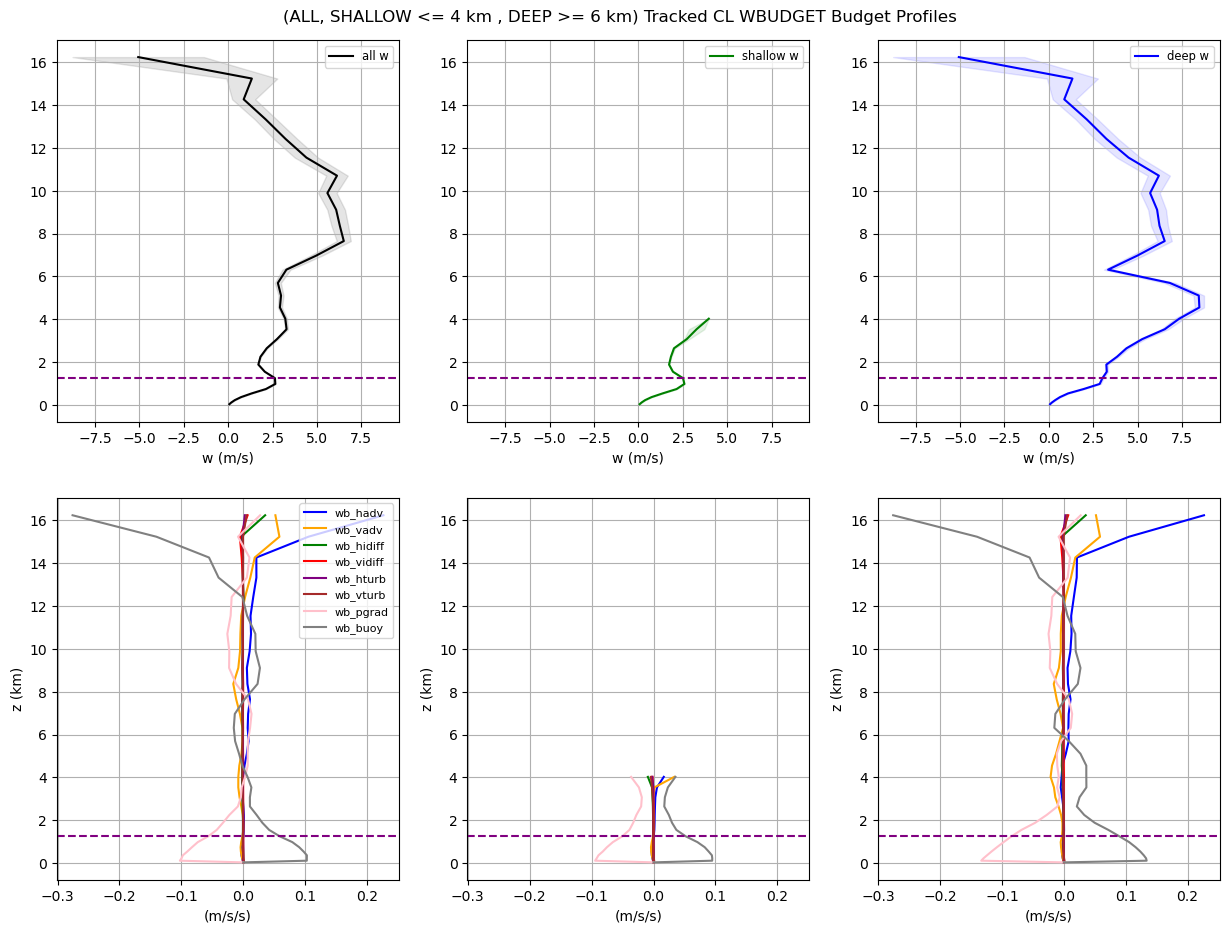

In [41]:
#CL W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked CL WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_WBUDGET_profile_all.h5'
        elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_WBUDGET_profile_shallow.h5'
        elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    bottommin=[];topmin=[];topmin=[];topmax=[]
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        
    if type=='all':        
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        PlotSE(profile_w, out_w, W, colors[0], axis,type)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        PlotSE(profile_w, out_w, W, colors[3], axis, type)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        PlotSE(profile_w, out_w, W, colors[1], axis, type)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

In [42]:
#CL QV Budgets

#'qv budget: horizontal advection (non-diff component)'
#'qv budget: vertical advection (non-diff component)'
#'qv budget: horiz implicit diffusion'
#'qv budget: vert implicit diffusion'
#'qv budget: horizontal parameterized turbulence'
#'qv budget: vertical parameterized turbulence'
#'qv budget: microphysics scheme'
variables = [QV,QVB_HADV,QVB_VADV,QVB_HIDIFF,QVB_VIDIFF,QVB_HTURB,QVB_VTURB,QVB_MP]


types=['all','shallow','deep']
vars = [
    'qv',
    'qvb_hadv',
    'qvb_vadv',
    'qvb_hidiff',
    'qvb_vidiff',
    'qvb_hturb',
    'qvb_vturb',
    'qvb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for (var,variable) in zip(vars,variables):
            globals()[f"profile_{var}"]=CL_tracked_profile(variable,type=type)
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/CL_all_QVBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_QVBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_QVBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")
        f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")
        f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")
        f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")
        f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")
        f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")
        f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")
    print('done')

type all
done
type shallow
done
type deep
done


currently on type all
currently on type shallow
currently on type deep
(-0.7589311272464968, 16.00002045573654)
(-0.7796000954695046, 17.05360203469172)
(-0.01765349571403167, 0.021135458337084856)
(-0.7796000954695046, 17.05360203469172)


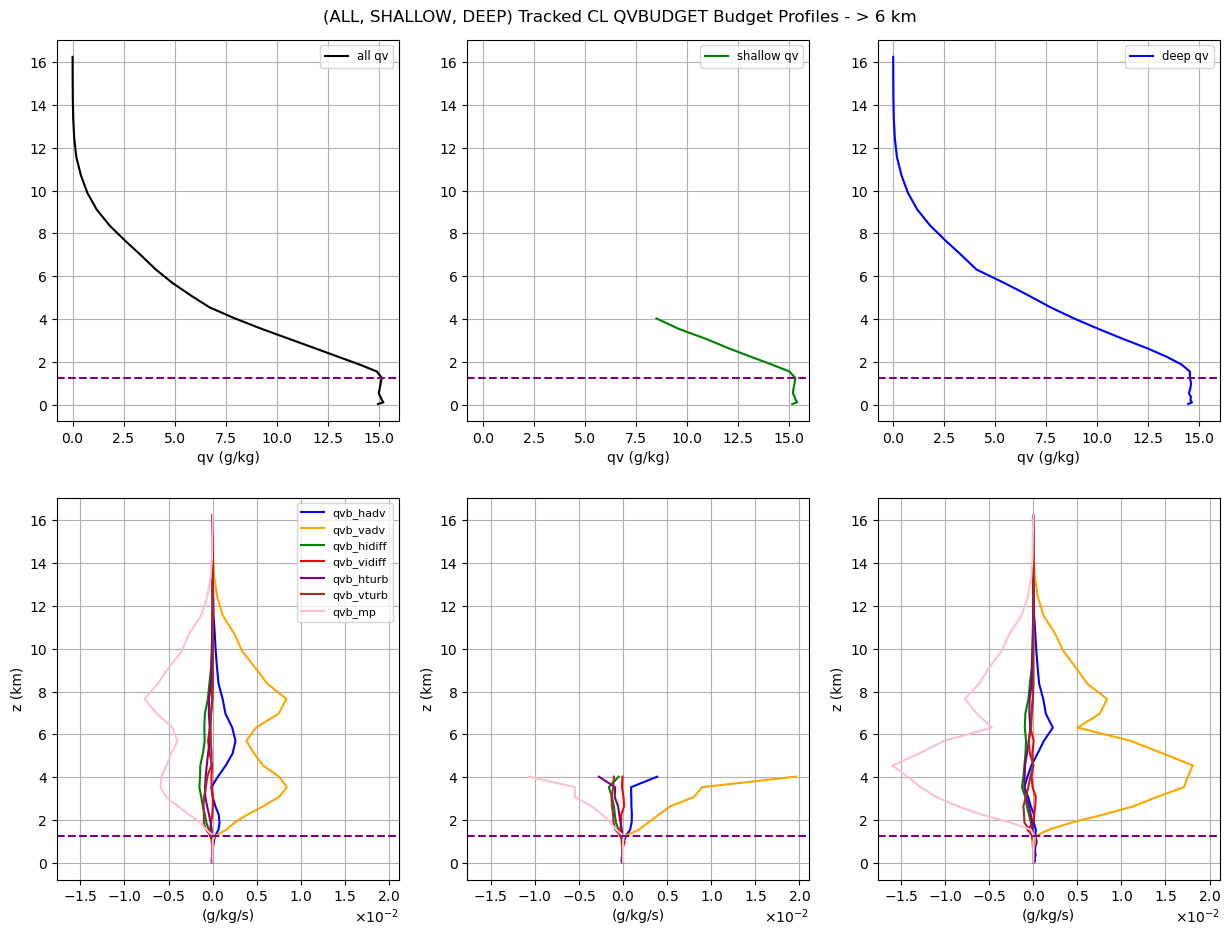

In [43]:
#QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL QVBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_QVBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_QVBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        globals()[f"out_{var}"][:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        PlotSE(profile_qv, out_qv, QV, colors[0], axis,type)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        PlotSE(profile_qv, out_qv, QV, colors[3], axis,type)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        PlotSE(profile_qv, out_qv, QV, colors[1], axis,type)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend


#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CL_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [65]:
#CL TH Budgets

variables = [TH,PTB_HADV,PTB_VADV,PTB_HIDIFF,PTB_VIDIFF,PTB_HTURB,PTB_VTURB,PTB_MP]

types=['all','shallow','deep']
vars = [
    'th',
    'ptb_hadv',
    'ptb_vadv',
    'ptb_hidiff',
    'ptb_vidiff',
    'ptb_hturb',
    'ptb_vturb',
    'ptb_mp'
]

for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for (var,variable) in zip(vars,variables):
            globals()[f"profile_{var}"]=CL_tracked_profile(variable,type=type)              
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/CL_all_THBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_THBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_ptb_hadv', data=profile_ptb_hadv, compression="gzip")
        f.create_dataset('profile_ptb_vadv', data=profile_ptb_vadv, compression="gzip")
        f.create_dataset('profile_ptb_hidiff', data=profile_ptb_hidiff, compression="gzip")
        f.create_dataset('profile_ptb_vidiff', data=profile_ptb_vidiff, compression="gzip")
        f.create_dataset('profile_ptb_hturb', data=profile_ptb_hturb, compression="gzip")
        f.create_dataset('profile_ptb_vturb', data=profile_ptb_vturb, compression="gzip")
        f.create_dataset('profile_ptb_mp', data=profile_ptb_mp, compression="gzip")
    print('done')

type all
done
type shallow
done
type deep
done


currently on type all
currently on type shallow
currently on type deep
(302.1305360935801, 377.3902900310766)
(-0.7796000954695046, 17.05360203469172)
(-0.16787707585220538, 0.15945710704351465)
(-0.7796000954695046, 17.05360203469172)


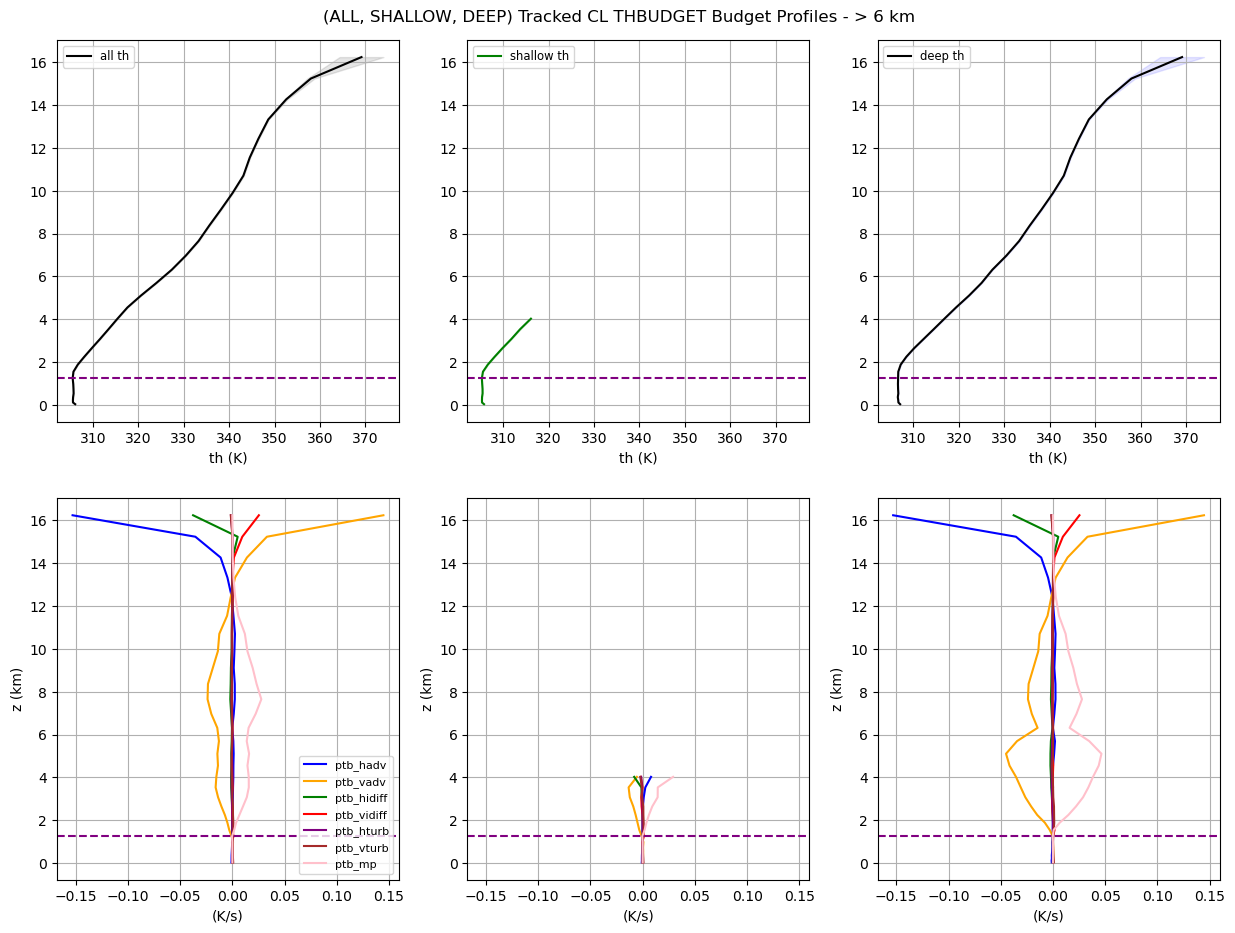

In [66]:
#TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL THBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_THBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_THBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_THBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        PlotSE(profile_th, out_th, TH, colors[0], axis,type)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        PlotSE(profile_th, out_th, TH, colors[3], axis,type)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        PlotSE(profile_th, out_th, TH, colors[1], axis,type)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower right', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CL_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [47]:
def nonCL_tracked_profile(var_data,type):
    if type=='all':
        out_arr=ALL_save_arr.copy()
        after_array=ALL_save_after_array
    elif type=='shallow':
        out_arr=SHALLOW_save_arr.copy()
        after_array=SHALLOW_save_after_array
    elif type=='deep':
        out_arr=DEEP_save_arr.copy()
        after_array=DEEP_save_after_array
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=after_array[row]
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        vars=var_data[ts,p]
        np.add.at(profile_array[:, 0], zs, vars)
        np.add.at(profile_array[:, 1], zs, 1)
    return profile_array

In [48]:
#Deep Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#nonCL W Budgets
#'w': vertical velocity
#'w budget: horizontal advection (non-diff component)'
#'w budget: vertical advection (non-diff component)'
#'w budget: horiz implicit diffusion'
#'w budget: vert implicit diffusion'
#'w budget: horizontal parameterized turbulence'
#'w budget: vertical parameterized turbulence'
#'w budget: pressure gradient'
#'w budget: buoyancy'
variables = [W,WB_HADV,WB_VADV,WB_HIDIFF,WB_VIDIFF,WB_HTURB,WB_VTURB,WB_PGRAD,WB_BUOY]
types=['all','shallow','deep']
vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for (var,variable) in zip(vars,variables):
            globals()[f"profile_{var}"]=nonCL_tracked_profile(variable,type=type)
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_WBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_WBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
        f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
        f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
        f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
        f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
        f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
        f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
        f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")
    print('done')

type all
done
type shallow
done
type deep
done


currently on type all
currently on type shallow
currently on type deep
(-3.2863504607854033, 9.609502349985908)
(-0.8313374039717019, 18.140085513237864)
(-0.7468329414725303, 0.42375547140836717)
(-0.8313374039717019, 18.140085513237864)


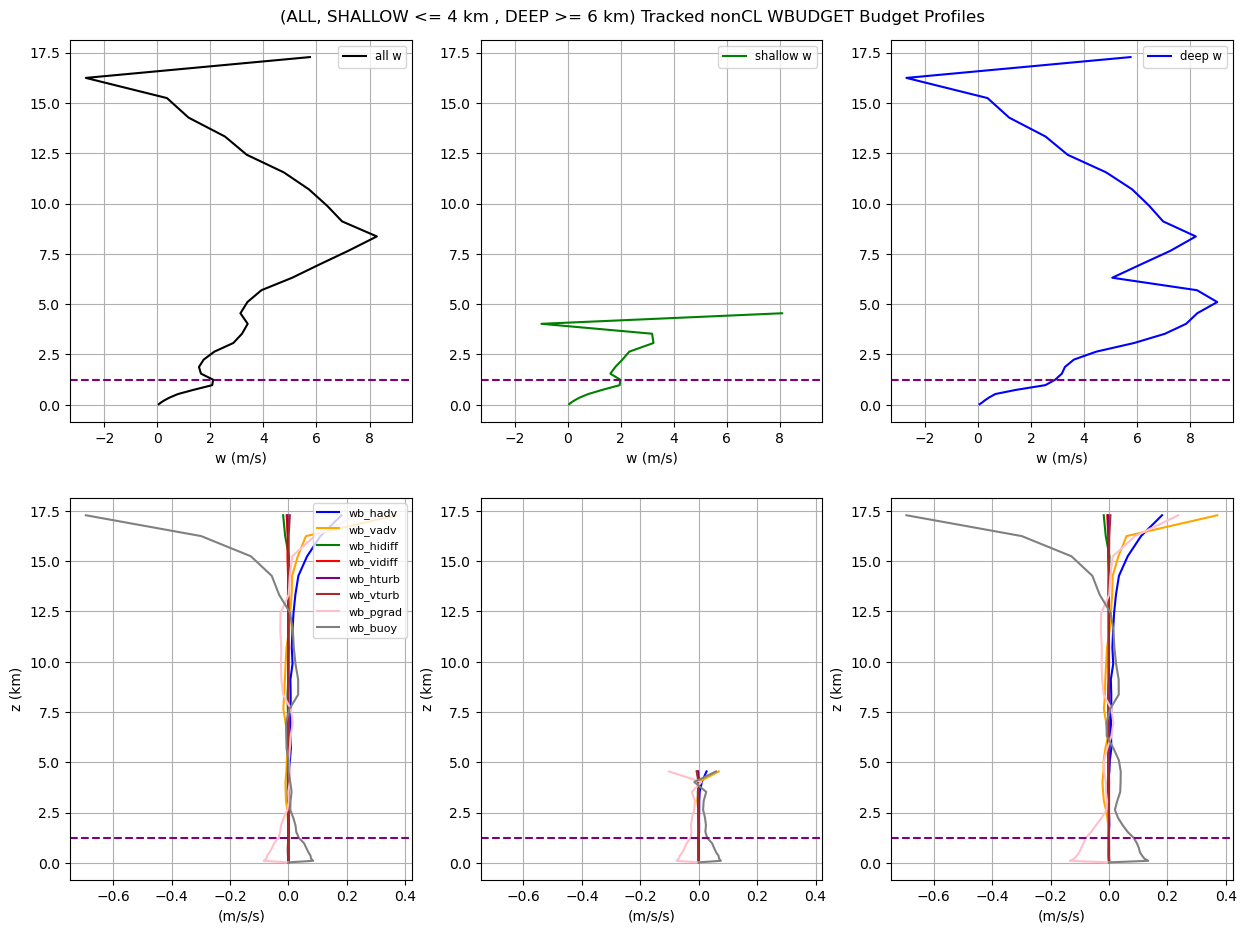

In [56]:
#nonCL W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked nonCL WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_WBUDGET_profile_all.h5'
        elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_WBUDGET_profile_shallow.h5'
        elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    bottommin=[];topmin=[];topmin=[];topmax=[]
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # PlotSE(profile_w, out_w, W, colors[0], axis, type)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        # PlotSE(profile_w, out_w, W, colors[3], axis, type)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        # PlotSE(profile_w, out_w, W, colors[1], axis, type)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_save_nz),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_save_nz),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_save_nz),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonCL_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

In [51]:
#nonCL QV Budgets

#'qv budget: horizontal advection (non-diff component)'
#'qv budget: vertical advection (non-diff component)'
#'qv budget: horiz implicit diffusion'
#'qv budget: vert implicit diffusion'
#'qv budget: horizontal parameterized turbulence'
#'qv budget: vertical parameterized turbulence'
#'qv budget: microphysics scheme'
variables = [QV,QVB_HADV,QVB_VADV,QVB_HIDIFF,QVB_VIDIFF,QVB_HTURB,QVB_VTURB,QVB_MP]


types=['all','shallow','deep']
vars = [
    'qv',
    'qvb_hadv',
    'qvb_vadv',
    'qvb_hidiff',
    'qvb_vidiff',
    'qvb_hturb',
    'qvb_vturb',
    'qvb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for (var,variable) in zip(vars,variables):
            globals()[f"profile_{var}"]=nonCL_tracked_profile(variable,type=type)
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_QVBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_QVBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_QVBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")
        f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")
        f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")
        f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")
        f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")
        f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")
        f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")
    print('done')

type all
done
type shallow
done
type deep
done


currently on type all
currently on type shallow
currently on type deep
(-0.7922586418876554, 16.662238758446147)
(-0.8313374039717019, 18.140085513237864)
(-0.019182396044925554, 0.02683214324861183)
(-0.8313374039717019, 18.140085513237864)


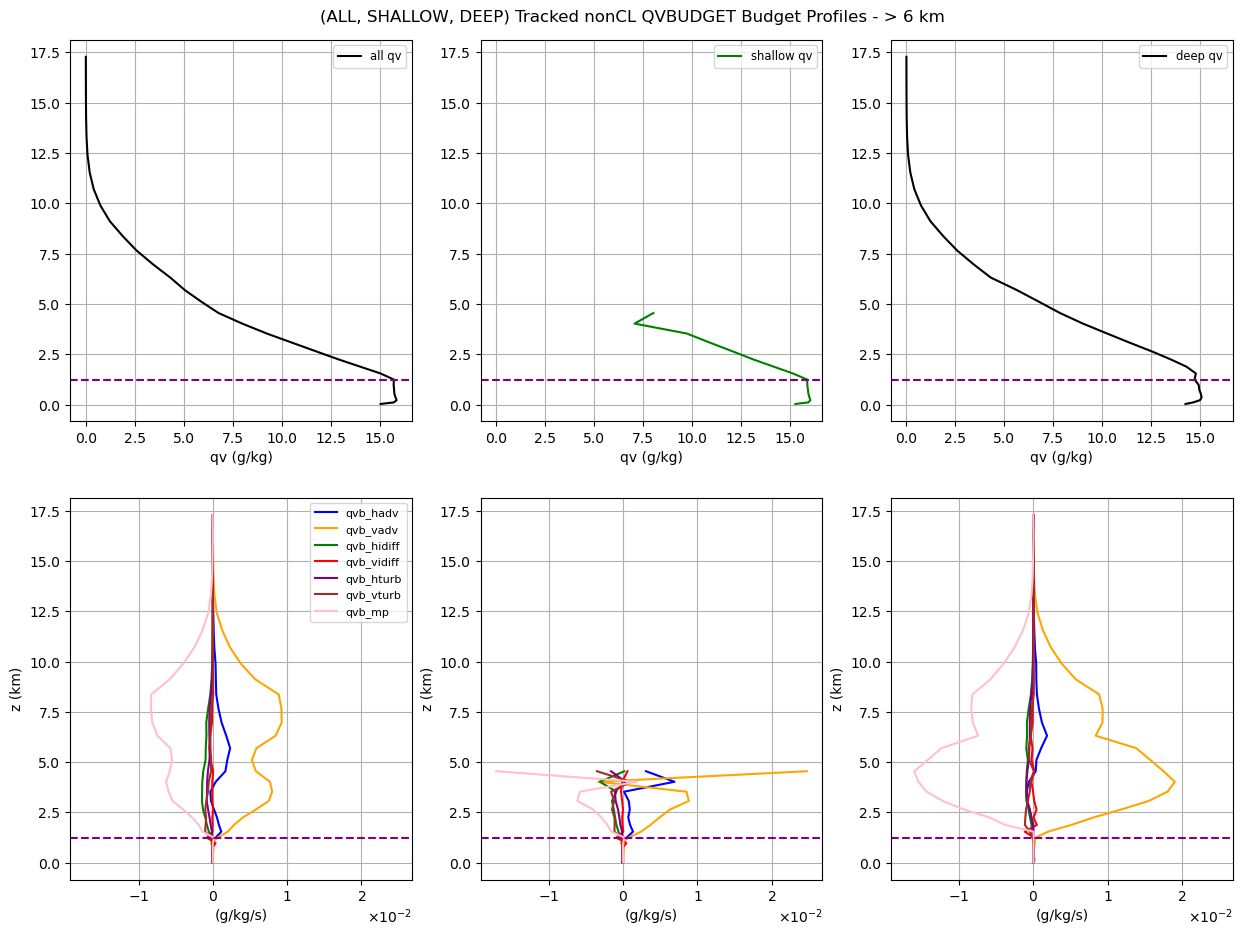

In [52]:
#nonCL QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked nonCL QVBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_QVBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_QVBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        globals()[f"out_{var}"][:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # PlotSE(profile_qv, out_qv, QV, colors[0], axis, type)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        # PlotSE(profile_qv, out_qv, QV, colors[3], axis, type)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        # PlotSE(profile_qv, out_qv, QV, colors[1], axis, type)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_save_nz),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_save_nz),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_save_nz),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonCL_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [68]:
#CL TH Budgets

variables = [TH,PTB_HADV,PTB_VADV,PTB_HIDIFF,PTB_VIDIFF,PTB_HTURB,PTB_VTURB,PTB_MP]

types=['all','shallow','deep']
vars = [
    'th',
    'ptb_hadv',
    'ptb_vadv',
    'ptb_hidiff',
    'ptb_vidiff',
    'ptb_hturb',
    'ptb_vturb',
    'ptb_mp'
]

for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for (var,variable) in zip(vars,variables):
            globals()[f"profile_{var}"]=nonCL_tracked_profile(variable,type=type) 
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_THBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_THBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_ptb_hadv', data=profile_ptb_hadv, compression="gzip")
        f.create_dataset('profile_ptb_vadv', data=profile_ptb_vadv, compression="gzip")
        f.create_dataset('profile_ptb_hidiff', data=profile_ptb_hidiff, compression="gzip")
        f.create_dataset('profile_ptb_vidiff', data=profile_ptb_vidiff, compression="gzip")
        f.create_dataset('profile_ptb_hturb', data=profile_ptb_hturb, compression="gzip")
        f.create_dataset('profile_ptb_vturb', data=profile_ptb_vturb, compression="gzip")
        f.create_dataset('profile_ptb_mp', data=profile_ptb_mp, compression="gzip")
    print('done')

type all
done
type shallow
done
type deep
done


currently on type all
currently on type shallow
currently on type deep
(301.3378046279398, 375.14206196805196)
(-0.8313374039717019, 18.140085513237864)
(-0.12993276845663787, 0.12198952194303274)
(-0.8313374039717019, 18.140085513237864)


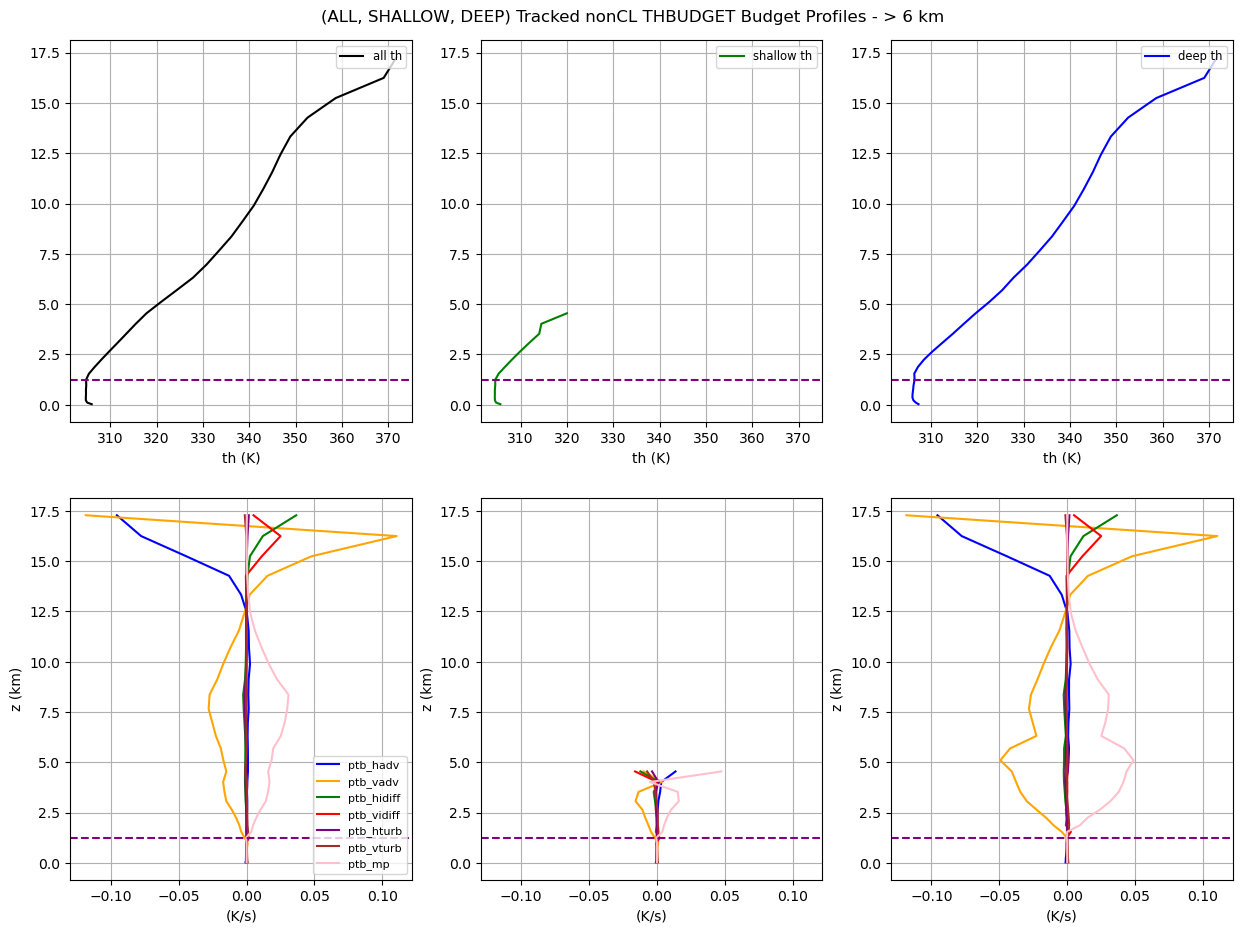

In [69]:
#nonCL TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked nonCL THBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_THBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_THBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_THBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # PlotSE(profile_th, out_th, TH, colors[0], axis, type)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        # PlotSE(profile_th, out_th, TH, colors[3], axis, type)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        # PlotSE(profile_th, out_th, TH, colors[1], axis, type)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower right', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_save_nz),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_save_nz),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_save_nz),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonCL_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [ ]:
#CL minus nonCL

In [57]:
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

currently on type all
currently on type shallow
currently on type deep
(-2.530277703127835, 5.225713605040028)
(-0.7796000954695046, 17.05360203469172)
(-0.07092428722108404, 0.1257439497175316)
(-0.7796000954695046, 17.05360203469172)


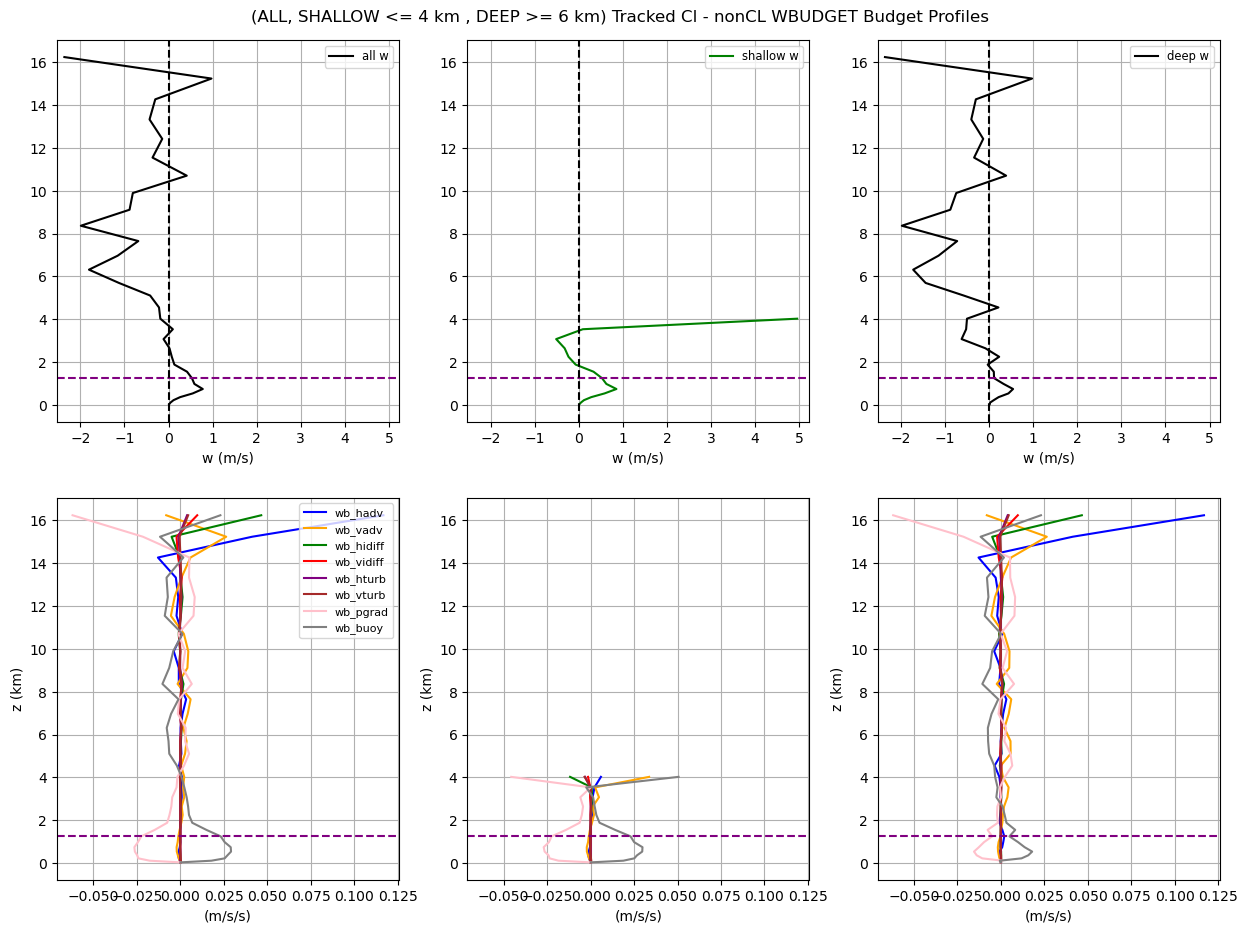

In [60]:
#CL-nonCL W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked Cl - nonCL WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

    if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_WBUDGET_profile_all.h5'
    elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w1 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv1 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv1 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff1 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff1 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb1 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb1 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad1 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy1 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy
    
    if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_WBUDGET_profile_all.h5'
    elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w2 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv2 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv2 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff2 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff2 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb2 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb2 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad2 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy2 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_arr), mean_LFC(ALL_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_out_arr), mean_LFC(SHALLOW_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_out_arr), mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CLminusnonCL_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.855892357681815, 1.5509417467389137)
(-0.7796000954695046, 17.05360203469172)
(-0.01423445838284465, 0.024729298494463592)
(-0.7796000954695046, 17.05360203469172)


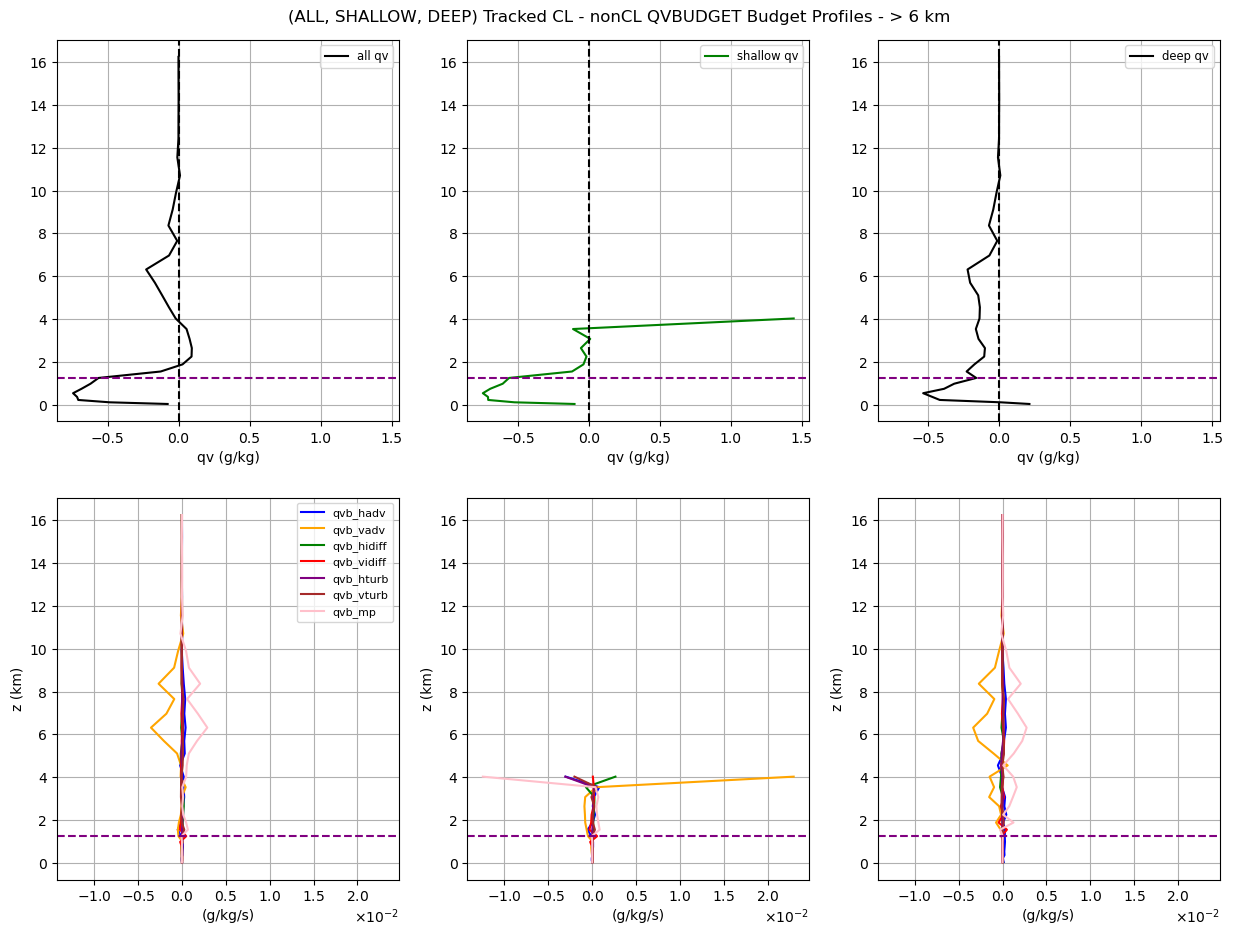

In [61]:
#CL - nonCL QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL - nonCL QVBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

     
    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_QVBUDGET_profile_all.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_QVBUDGET_profile_shallow.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv1 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv1 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv1 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff1 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff1 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb1 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb1 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp1 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_QVBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_QVBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv2 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv2 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv2 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff2 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff2 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb2 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb2 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp2 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        globals()[f"out_{var}"][:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_arr), mean_LFC(ALL_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_out_arr), mean_LFC(SHALLOW_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_out_arr), mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

    
#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/ClminusnonCL_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(-0.6970753677512391, 1.7711514100795853)
(-0.7796000954695046, 17.05360203469172)
(-0.08073102183019122, 0.039505047692606834)
(-0.7796000954695046, 17.05360203469172)


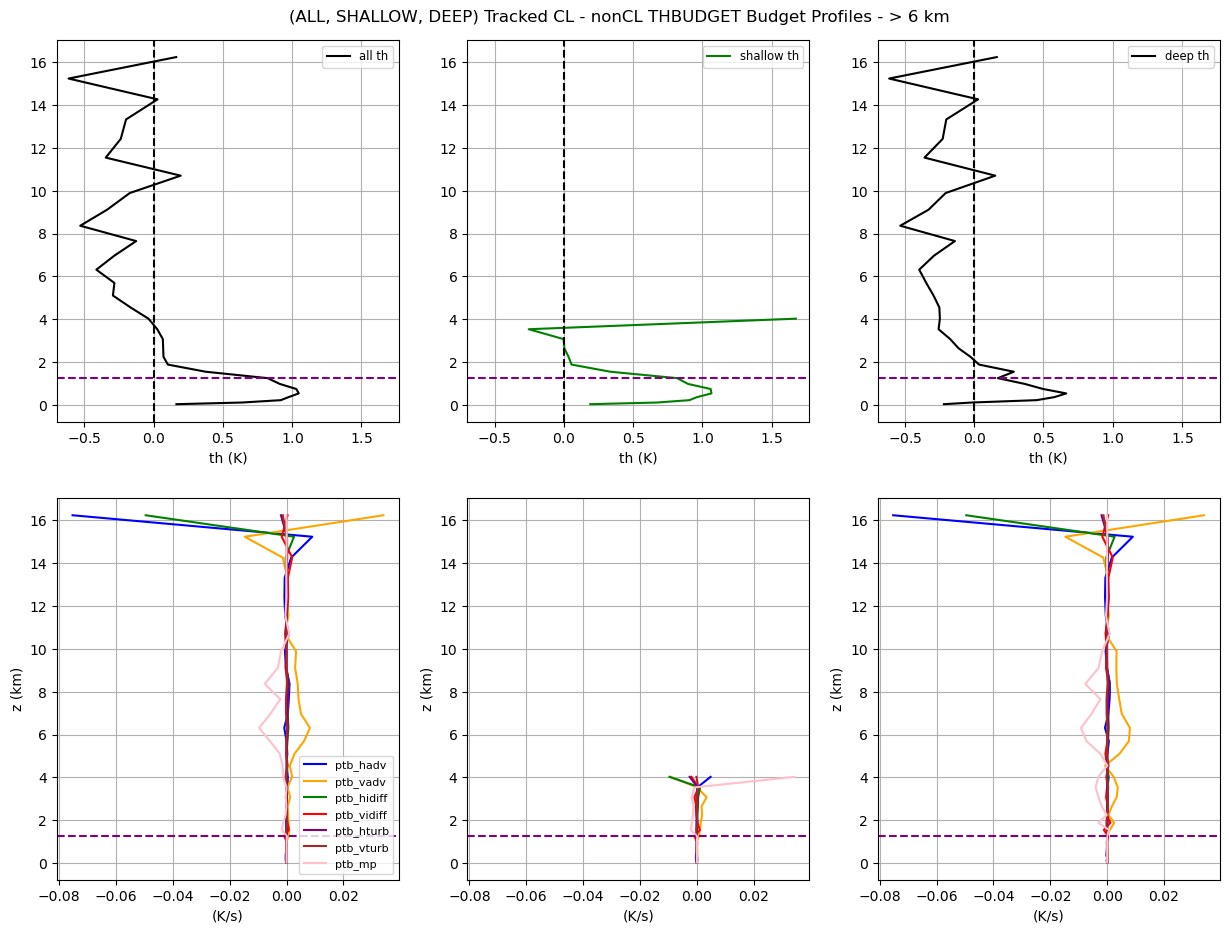

In [70]:
#CL - nonCL TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL - nonCL THBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')


    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_THBUDGET_profile_all.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_THBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th1 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv1 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv1 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff1 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff1 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb1 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb1 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp1 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient

    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_THBUDGET_profile_all.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_THBUDGET_profile_deep.h5'

    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th2 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv2 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv2 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff2 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff2 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb2 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb2 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp2 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower right', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_arr), mean_LFC(ALL_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_out_arr), mean_LFC(SHALLOW_save_nz))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_out_arr), mean_LFC(DEEP_save_nz))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax1, ax2, ax3])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CLminusnonCL_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [71]:
#FINDING SBZ CONVERGENCE
parcel_z=parcel['z'].data

#FIND ALL X MAXES
import sys
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir+'../Functions'
sys.path.append(path)
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# TF=False
# if TF==False:
#     print('Loading In Data')
#     u_data=data['u'].interp(xf=data['xh']).data
#     v_data=data['v'].interp(yf=data['yh']).data
#     TF=True


from NumericalFunctions import *
def find_SBZ_xmaxs():
    
    # print('calculating convergence and taking mean')
    # Conv=-(Ddx(u_data,1000)+Ddy(v_data,1000))
    dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}' + '.h5'
    with h5py.File(file_path, 'r') as f:
        Conv = f['conv'][:]
    
    zlev=4
    Conv_ymean=np.mean(Conv[:,zlev],axis=1)
    xmaxs=np.argmax(Conv_ymean, axis=1)

    return xmaxs
def find_SBZ_xmaxs():
    # Define the directory and file path
    dir2 = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}_{Np_str}' + '.h5'
    
    # Open the HDF5 file in read mode
    with h5py.File(file_path, 'r') as f:
        # Access the 'conv' dataset
        conv_dataset = f['conv']
        
        # Define the vertical level you are interested in
        zlev = 4
        
        # Initialize a list to store the xmaxs for each time step
        xmaxs_list = []

        # Loop over each time step (axis=0 corresponds to time)
        for t in range(conv_dataset.shape[0]):  # conv_dataset.shape[0] is the time dimension size
            # Read the relevant slice for this time step and vertical level
            Conv_t_zlev = conv_dataset[t, zlev, :, :]  # Shape should be (y_size, x_size)
            
            # Calculate the mean across the y-axis
            Conv_ymean = np.mean(Conv_t_zlev, axis=0)  # Mean across the y-axis
            
            # Find the index of the maximum value along the x-axis
            xmax = np.argmax(Conv_ymean)
            
            # Append the result for this time step
            xmaxs_list.append(xmax)
    
    # Convert the list of xmaxs to a numpy array (optional)
    xmaxs = np.array(xmaxs_list)

    return xmaxs #returns SBZ x location for each timestep


def subset_SBZ(out_arr):
    xmaxs=find_SBZ_xmaxs()

    SBZ_subset=[]
    # test=[] #TESTING
    
    for ind in np.arange(out_arr.shape[0]):
        
        row=out_arr[ind]
        p=row[0]
        t=row[1]

        kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
        if X[t,p] in np.arange( (xmaxs[t]-2*kms),(xmaxs[t]+2*kms) +1):
            SBZ_subset.append(ind)
            # test.append(p) #TESTING
    
    SBZ_out_arr=out_arr[SBZ_subset]
    print(f'there are a total of {len(SBZ_out_arr)} ALL SBZ CL parcels')

    valid_range=np.arange(out_arr.shape[0])
    nonSBZ_out_arr=out_arr[list(set(valid_range) - set(SBZ_subset))]
    print(f'there are a total of {len(nonSBZ_out_arr)} ALL nonSBZ CL parcels')
    return SBZ_out_arr,nonSBZ_out_arr


# #LOADING CL MAXS FROM CL TRACKING ALGORITHM
# folder = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Project_Algorithms/Tracking_Algorithms/'
# whereSBZ=xr.open_dataset(folder+f'whereCL_{res}_ONLY_SBZS.nc').load()
# whereSBZ=whereSBZ.isel(time=slice(0,len(data['time'])))
# whereSBZ=whereSBZ['maxconv_x']
# def Get_SBZ_X(t,z,y):
#     Conv_X_Max=whereSBZ[t,z,y,:].values
#     return Conv_X_Max
# def subset_SBZ(out_arr):

#     SBZ_subset=[]
#     # test=[] #TESTING
    
#     for ind in np.arange(out_arr.shape[0]):
        
#         row=out_arr[ind]
#         p=row[0]
#         t=row[1]

#         kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
#         value=X[t,p]
#         if np.any((value >= xmaxs - 2*kms) & (value <= xmaxs + 2*kms))==True:
#             SBZ_subset.append(ind)
#             # test.append(p) #TESTING
    
#     SBZ_out_arr=out_arr[SBZ_subset]
#     print(f'there are a total of {len(SBZ_out_arr)} ALL SBZ CL parcels')

#     valid_range=np.arange(out_arr.shape[0])
#     nonSBZ_out_arr=out_arr[list(set(valid_range) - set(SBZ_subset))]
#     print(f'there are a total of {len(nonSBZ_out_arr)} ALL nonSBZ CL parcels')
#     return SBZ_out_arr,nonSBZ_out_arr

#SUBSETTING OUT SHALLOW AND DEEP FROM SBZ AND NONSBZ
def SHALLOW_threshold(zthresh,type):
    if type=='SBZ':
        out_arr=ALL_SBZ_out_arr.copy()
    if type=='nonSBZ':
        out_arr=ALL_nonSBZ_out_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        # if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
        
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)

def DEEP_threshold(zthresh,type):
    if type=='SBZ':
        out_arr=ALL_SBZ_out_arr.copy()
    if type=='nonSBZ':
        out_arr=ALL_nonSBZ_out_arr.copy()

    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        # if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 
        
        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
    
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################
[ALL_SBZ_out_arr,ALL_nonSBZ_out_arr]=subset_SBZ(ALL_out_arr)
SHALLOW_SBZ_out_arr=SHALLOW_threshold(4,'SBZ')
print(f'there are a total of {len(SHALLOW_SBZ_out_arr)} SHALLOW SBZ CL parcels')
SHALLOW_nonSBZ_out_arr=SHALLOW_threshold(4,'nonSBZ')
print(f'there are a total of {len(SHALLOW_nonSBZ_out_arr)} SHALLOW nonSBZ CL parcels')
DEEP_SBZ_out_arr=DEEP_threshold(6,'SBZ')
print(f'there are a total of {len(DEEP_SBZ_out_arr)} DEEP SBZ CL parcels')
DEEP_nonSBZ_out_arr=DEEP_threshold(6,'nonSBZ')
print(f'there are a total of {len(DEEP_nonSBZ_out_arr)} DEEP nonSBZ CL parcels')

there are a total of 827 ALL SBZ CL parcels
there are a total of 14114 ALL nonSBZ CL parcels
there are a total of 432 SHALLOW SBZ CL parcels
there are a total of 10087 SHALLOW nonSBZ CL parcels
there are a total of 189 DEEP SBZ CL parcels
there are a total of 1331 DEEP nonSBZ CL parcels


In [93]:
#SBZ After Arrays
ALL_SBZ_out_after_array=find_after_time(ALL_SBZ_out_arr)
SHALLOW_SBZ_out_after_array=np.zeros(len(SHALLOW_SBZ_out_arr),dtype=int)
DEEP_SBZ_out_after_array=find_after_time(DEEP_SBZ_out_arr)

ALL_nonSBZ_out_after_array=find_after_time(ALL_nonSBZ_out_arr)
SHALLOW_nonSBZ_out_after_array=np.zeros(len(SHALLOW_nonSBZ_out_arr),dtype=int)
DEEP_nonSBZ_out_after_array=find_after_time(DEEP_nonSBZ_out_arr)

In [73]:
#FINDING MEAN CLOUD BASE #*****************************
zh=data['zh'].values
w_thresh2=0.5
qcqi_thresh=1e-6
type='all'


if type=='all':
    out_arr=ALL_out_arr.copy()
if type=='deep':
    out_arr=DEEP_out_arr.copy()
if type=='shallow':
    out_arr=SHALLOW_out_arr.copy()

zhs=data['zh'].values
profile_array =np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
profile_array[:,1]=zhs;

# cloudbase_lst=[]
after=4 #20 minutes
for row in range(out_arr.shape[0]):
    if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
    p=out_arr[row,0]
    
    # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
    ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(out_arr[row, 1], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]

    ws=W[ts,p]
    qcqis=QCQI[ts,p]
    where=np.where((ws>=w_thresh2) & (qcqis>=qcqi_thresh))
    profile_array[zs[where],0]+=1
del after
# print(np.mean(cloudbase_lst))
# print(np.min(cloudbase_lst))
# plt.hist(cloudbase_lst,bins=40,orientation='horizontal');
all_cloudbase=zh[np.where(profile_array[:,0]!=0)[0][0]]
print(all_cloudbase)

0/14941
3000/14941
6000/14941
9000/14941
12000/14941
1.2463868


In [74]:
def SBZ_tracked_profile(var_data,type):

    if type=='all':
        out_arr=ALL_SBZ_out_arr.copy()
        after_array=ALL_SBZ_out_after_array.copy()
    elif type=='shallow':
        out_arr=SHALLOW_SBZ_out_arr.copy()
        after_array=SHALLOW_SBZ_out_after_array.copy()
    elif type=='deep':
        out_arr=DEEP_SBZ_out_arr.copy()
        after_array=DEEP_SBZ_out_after_array.copy()
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=after_array[row]
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        vars=var_data[ts,p]
        np.add.at(profile_array[:, 0], zs, vars)
        np.add.at(profile_array[:, 1], zs, 1)
    return profile_array

In [75]:
#Deep Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#W Budgets
#'w': vertical velocity
#'w budget: horizontal advection (non-diff component)'
#'w budget: vertical advection (non-diff component)'
#'w budget: horiz implicit diffusion'
#'w budget: vert implicit diffusion'
#'w budget: horizontal parameterized turbulence'
#'w budget: vertical parameterized turbulence'
#'w budget: pressure gradient'
#'w budget: buoyancy'
variables = [W,WB_HADV,WB_VADV,WB_HIDIFF,WB_VIDIFF,WB_HTURB,WB_VTURB,WB_PGRAD,WB_BUOY]
types=['all','shallow','deep']
vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for (var,variable) in zip(vars,variables):
            globals()[f"profile_{var}"]=SBZ_tracked_profile(variable,type=type)
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_WBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_WBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
        f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
        f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
        f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
        f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
        f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
        f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
        f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")
    print('done')

type all
done
type shallow
done
type deep
done


currently on type all
currently on type shallow
currently on type deep
(-2.6493895033285733, 9.646018342673779)
(-0.6809093949384988, 14.981097323540599)
(-0.11618886413176305, 0.09377163548756028)
(-0.6809093949384988, 14.981097323540599)


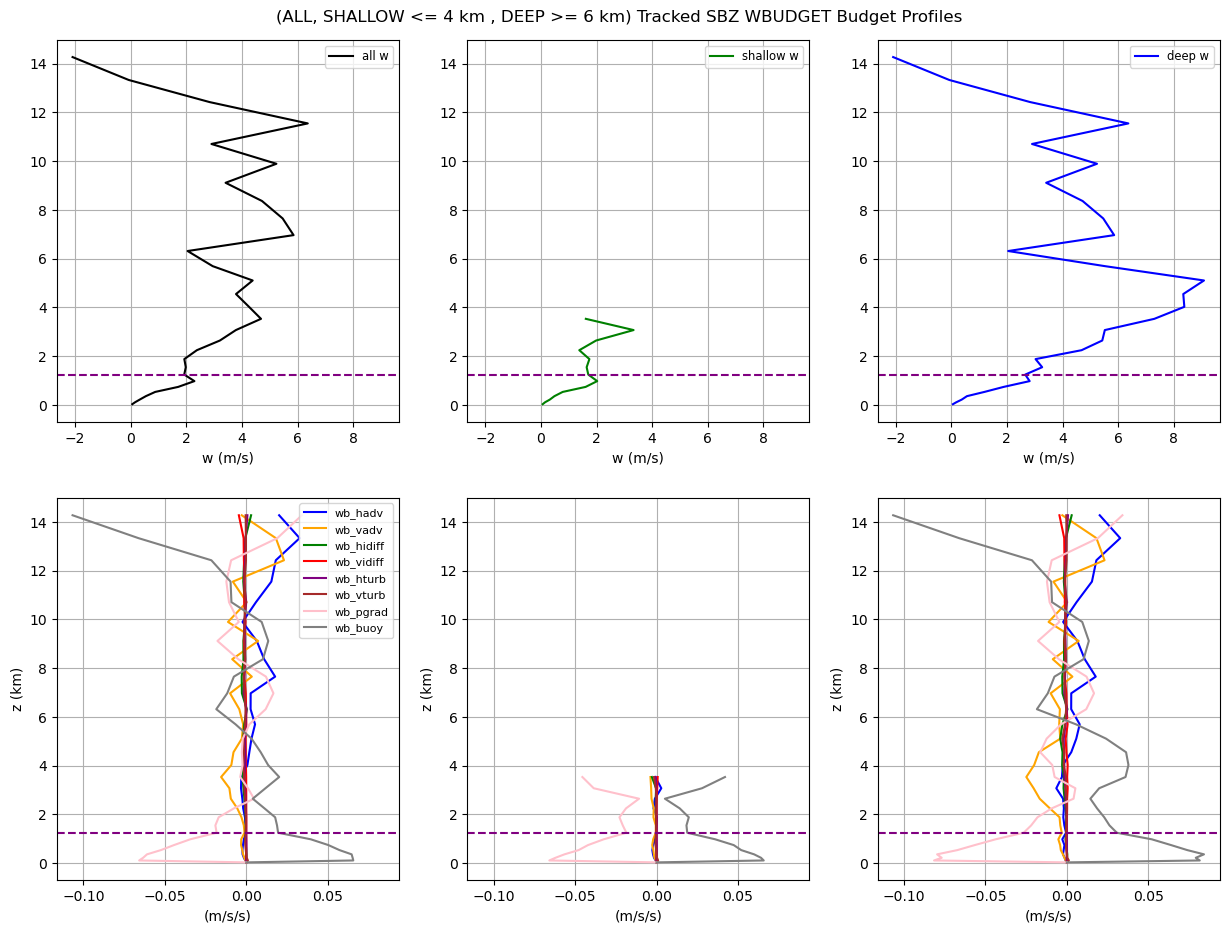

In [76]:
#SBZ W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked SBZ WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_WBUDGET_profile_all.h5'
        elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_WBUDGET_profile_shallow.h5'
        elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    bottommin=[];topmin=[];topmin=[];topmax=[]
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_SBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_SBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_SBZ_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZ_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

In [77]:
#CL QV Budgets

#'qv budget: horizontal advection (non-diff component)'
#'qv budget: vertical advection (non-diff component)'
#'qv budget: horiz implicit diffusion'
#'qv budget: vert implicit diffusion'
#'qv budget: horizontal parameterized turbulence'
#'qv budget: vertical parameterized turbulence'
#'qv budget: microphysics scheme'
variables = [QV,QVB_HADV,QVB_VADV,QVB_HIDIFF,QVB_VIDIFF,QVB_HTURB,QVB_VTURB,QVB_MP]


types=['all','shallow','deep']
vars = [
    'qv',
    'qvb_hadv',
    'qvb_vadv',
    'qvb_hidiff',
    'qvb_vidiff',
    'qvb_hturb',
    'qvb_vturb',
    'qvb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for (var,variable) in zip(vars,variables):
            globals()[f"profile_{var}"]=SBZ_tracked_profile(variable,type=type)
              
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_QVBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_QVBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_QVBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")
        f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")
        f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")
        f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")
        f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")
        f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")
        f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")
    print('done')

type all
done
type shallow
done
type deep
done


currently on type all
currently on type shallow
currently on type deep
(-0.8038030899367344, 17.110407718866615)
(-0.6809093949384988, 14.981097323540599)
(-0.017917440904618706, 0.02188828199363519)
(-0.6809093949384988, 14.981097323540599)


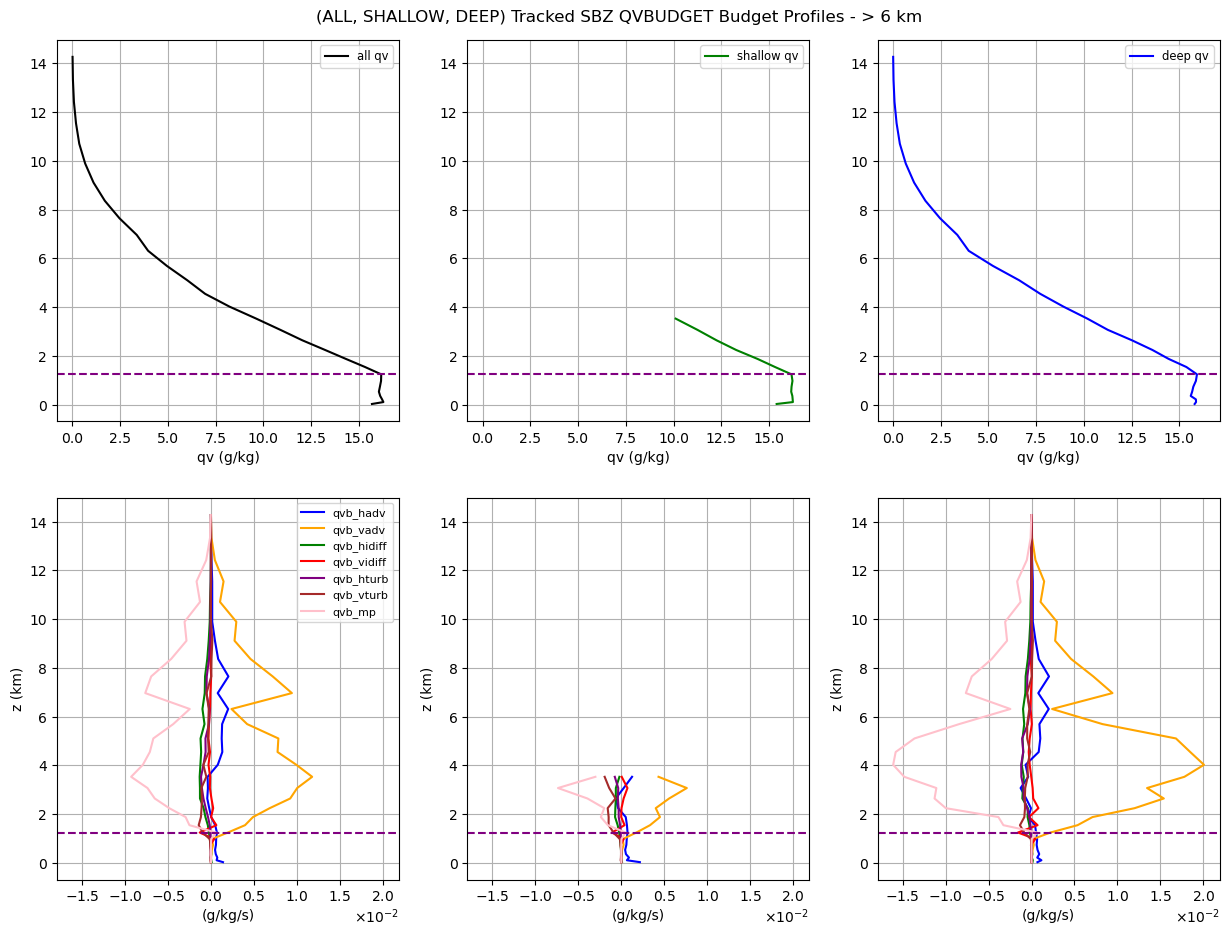

In [78]:
#QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ QVBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_QVBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_QVBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        globals()[f"out_{var}"][:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_SBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_SBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_SBZ_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZ_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [79]:
#CL TH Budgets

variables = [TH,PTB_HADV,PTB_VADV,PTB_HIDIFF,PTB_VIDIFF,PTB_HTURB,PTB_VTURB,PTB_MP]

types=['all','shallow','deep']
vars = [
    'th',
    'ptb_hadv',
    'ptb_vadv',
    'ptb_hidiff',
    'ptb_vidiff',
    'ptb_hturb',
    'ptb_vturb',
    'ptb_mp'
]

for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for (var,variable) in zip(vars,variables):
            globals()[f"profile_{var}"]=SBZ_tracked_profile(variable,type=type) 
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_THBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_THBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_ptb_hadv', data=profile_ptb_hadv, compression="gzip")
        f.create_dataset('profile_ptb_vadv', data=profile_ptb_vadv, compression="gzip")
        f.create_dataset('profile_ptb_hidiff', data=profile_ptb_hidiff, compression="gzip")
        f.create_dataset('profile_ptb_vidiff', data=profile_ptb_vidiff, compression="gzip")
        f.create_dataset('profile_ptb_hturb', data=profile_ptb_hturb, compression="gzip")
        f.create_dataset('profile_ptb_vturb', data=profile_ptb_vturb, compression="gzip")
        f.create_dataset('profile_ptb_mp', data=profile_ptb_mp, compression="gzip")
    print('done')

type all
done
type shallow
done
type deep
done


currently on type all
currently on type shallow
currently on type deep
(301.87997031934333, 352.90424620503126)
(-0.6809093949384988, 14.981097323540599)
(-0.050420856099697715, 0.05483886591973714)
(-0.6809093949384988, 14.981097323540599)


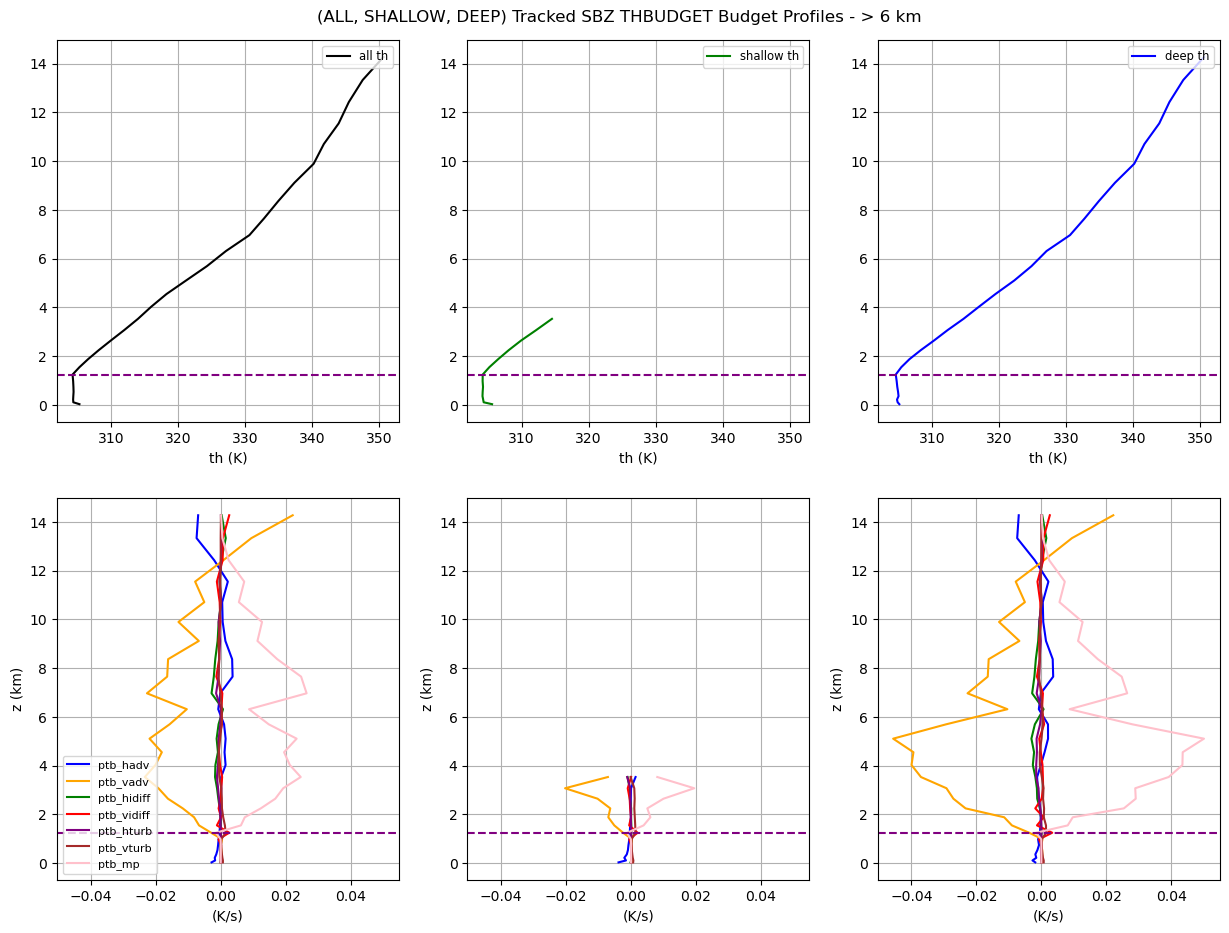

In [80]:
#TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ THBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_THBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_THBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_THBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower left', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_SBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_SBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_SBZ_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZ_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [95]:
def nonSBZ_tracked_profile(var_data,type):
    if type=='all':
        out_arr=ALL_nonSBZ_out_arr.copy()
        after_array=ALL_nonSBZ_out_after_array.copy()
    elif type=='shallow':
        out_arr=SHALLOW_nonSBZ_out_arr.copy()
        after_array=SHALLOW_nonSBZ_out_after_array.copy()
    elif type=='deep':
        out_arr=DEEP_nonSBZ_out_arr.copy()
        after_array=DEEP_nonSBZ_out_after_array.copy()
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=after_array[row]
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        vars=var_data[ts,p]
        np.add.at(profile_array[:, 0], zs, vars)
        np.add.at(profile_array[:, 1], zs, 1)
    return profile_array

In [98]:
#Deep Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#W Budgets
#'w': vertical velocity
#'w budget: horizontal advection (non-diff component)'
#'w budget: vertical advection (non-diff component)'
#'w budget: horiz implicit diffusion'
#'w budget: vert implicit diffusion'
#'w budget: horizontal parameterized turbulence'
#'w budget: vertical parameterized turbulence'
#'w budget: pressure gradient'
#'w budget: buoyancy'
variables = [W,WB_HADV,WB_VADV,WB_HIDIFF,WB_VIDIFF,WB_HTURB,WB_VTURB,WB_PGRAD,WB_BUOY]
types=['all','shallow','deep']
vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for (var,variable) in zip(vars,variables):
            globals()[f"profile_{var}"]=nonSBZ_tracked_profile(variable,type=type)
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_WBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_WBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
        f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
        f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
        f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
        f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
        f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
        f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
        f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")
    print('done')

type all
done
type shallow
done
type deep
done


currently on type all
currently on type shallow
currently on type deep
(-5.7418528521489485, 9.179386795864424)
(-0.7796000954695046, 17.05360203469172)
(-0.3008802050414185, 0.2515942747704685)
(-0.7796000954695046, 17.05360203469172)


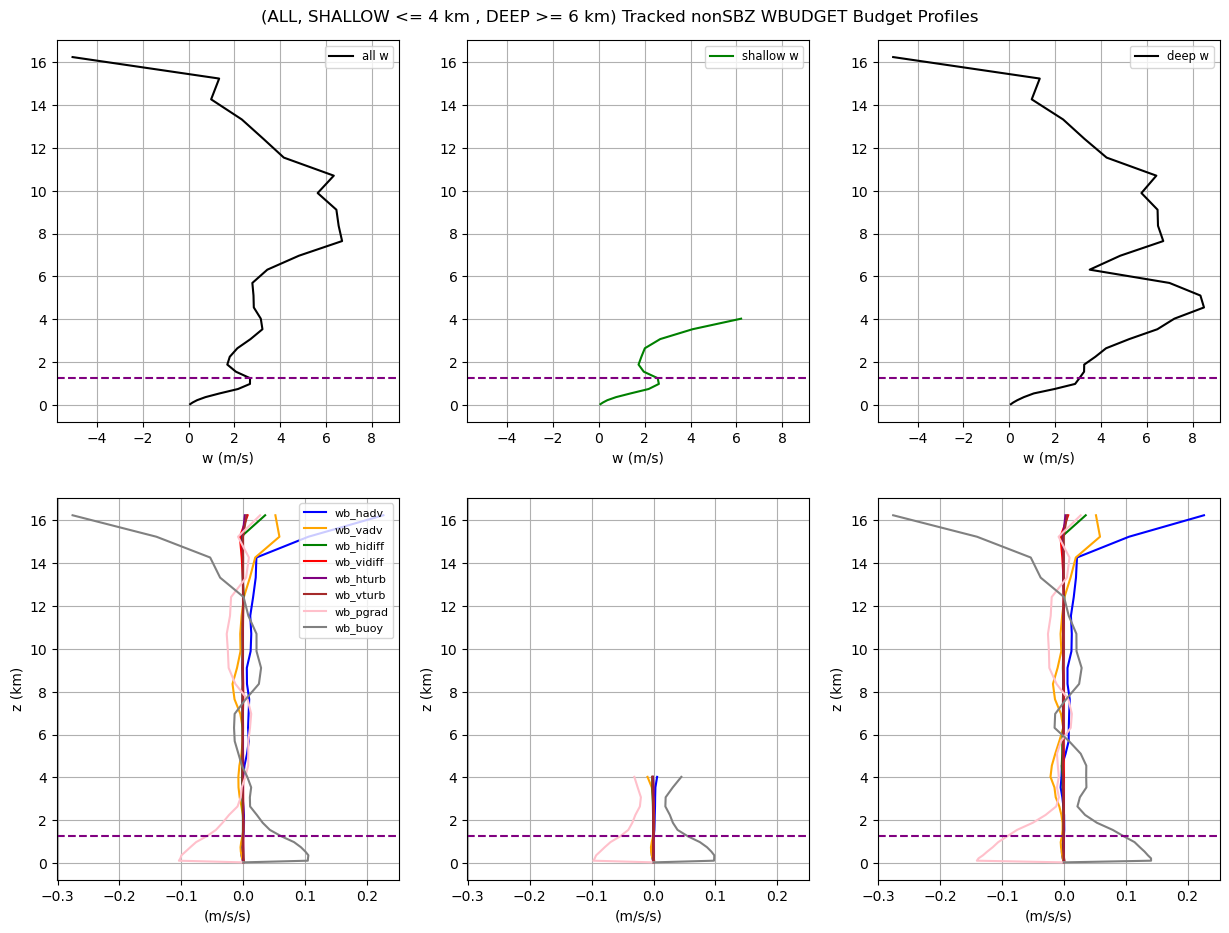

In [99]:
#nonSBZ W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked nonSBZ WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_WBUDGET_profile_all.h5'
        elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_WBUDGET_profile_shallow.h5'
        elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    bottommin=[];topmin=[];topmin=[];topmax=[]
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_nonSBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_nonSBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_nonSBZ_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')



#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonSBZ_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

In [96]:
#CL QV Budgets

#'qv budget: horizontal advection (non-diff component)'
#'qv budget: vertical advection (non-diff component)'
#'qv budget: horiz implicit diffusion'
#'qv budget: vert implicit diffusion'
#'qv budget: horizontal parameterized turbulence'
#'qv budget: vertical parameterized turbulence'
#'qv budget: microphysics scheme'
variables = [QV,QVB_HADV,QVB_VADV,QVB_HIDIFF,QVB_VIDIFF,QVB_HTURB,QVB_VTURB,QVB_MP]


types=['all','shallow','deep']
vars = [
    'qv',
    'qvb_hadv',
    'qvb_vadv',
    'qvb_hidiff',
    'qvb_vidiff',
    'qvb_hturb',
    'qvb_vturb',
    'qvb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for (var,variable) in zip(vars,variables):
            globals()[f"profile_{var}"]=nonSBZ_tracked_profile(variable,type=type)
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_QVBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_QVBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_QVBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")
        f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")
        f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")
        f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")
        f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")
        f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")
        f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")
    print('done')

type all
done
type shallow
done
type deep
done


currently on type all
currently on type shallow
currently on type deep
(-0.7565626768875982, 15.950296136647257)
(-0.7796000954695046, 17.05360203469172)
(-0.0176725376481139, 0.019746126645304618)
(-0.7796000954695046, 17.05360203469172)


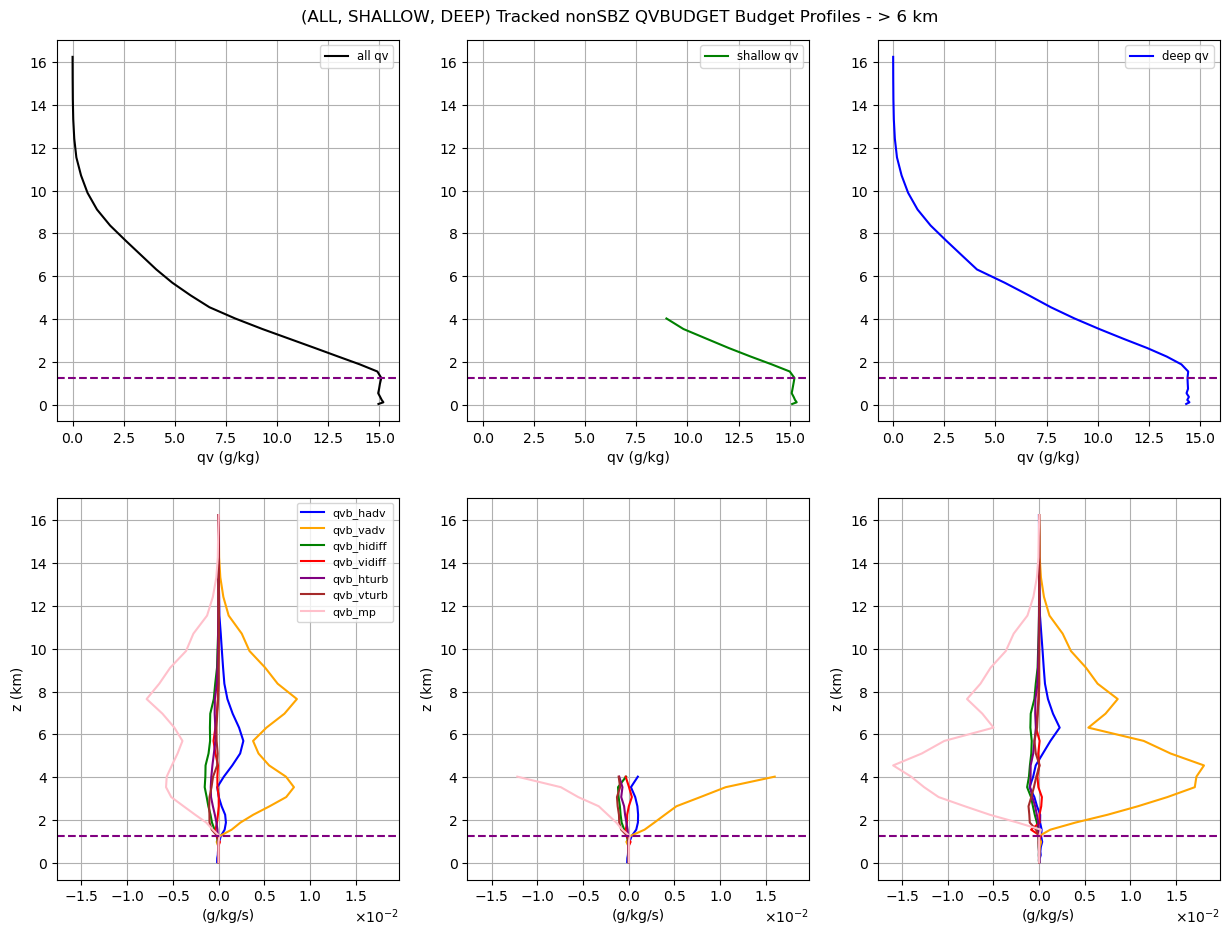

In [97]:
#QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked nonSBZ QVBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_QVBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_QVBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        globals()[f"out_{var}"][:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_nonSBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_nonSBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_nonSBZ_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonSBZ_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [100]:
#CL TH Budgets

variables = [TH,PTB_HADV,PTB_VADV,PTB_HIDIFF,PTB_VIDIFF,PTB_HTURB,PTB_VTURB,PTB_MP]

types=['all','shallow','deep']
vars = [
    'th',
    'ptb_hadv',
    'ptb_vadv',
    'ptb_hidiff',
    'ptb_vidiff',
    'ptb_hturb',
    'ptb_vturb',
    'ptb_mp'
]

for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for (var,variable) in zip(vars,variables):
            globals()[f"profile_{var}"]=nonSBZ_tracked_profile(variable,type=type)    
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_THBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_THBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_ptb_hadv', data=profile_ptb_hadv, compression="gzip")
        f.create_dataset('profile_ptb_vadv', data=profile_ptb_vadv, compression="gzip")
        f.create_dataset('profile_ptb_hidiff', data=profile_ptb_hidiff, compression="gzip")
        f.create_dataset('profile_ptb_vidiff', data=profile_ptb_vidiff, compression="gzip")
        f.create_dataset('profile_ptb_hturb', data=profile_ptb_hturb, compression="gzip")
        f.create_dataset('profile_ptb_vturb', data=profile_ptb_vturb, compression="gzip")
        f.create_dataset('profile_ptb_mp', data=profile_ptb_mp, compression="gzip")
    print('done')

type all
done
type shallow
done
type deep
done


currently on type all
currently on type shallow
currently on type deep
(302.49101003802497, 372.3211833405132)
(-0.7796000954695046, 17.05360203469172)
(-0.16787707585220538, 0.15945710704351465)
(-0.7796000954695046, 17.05360203469172)


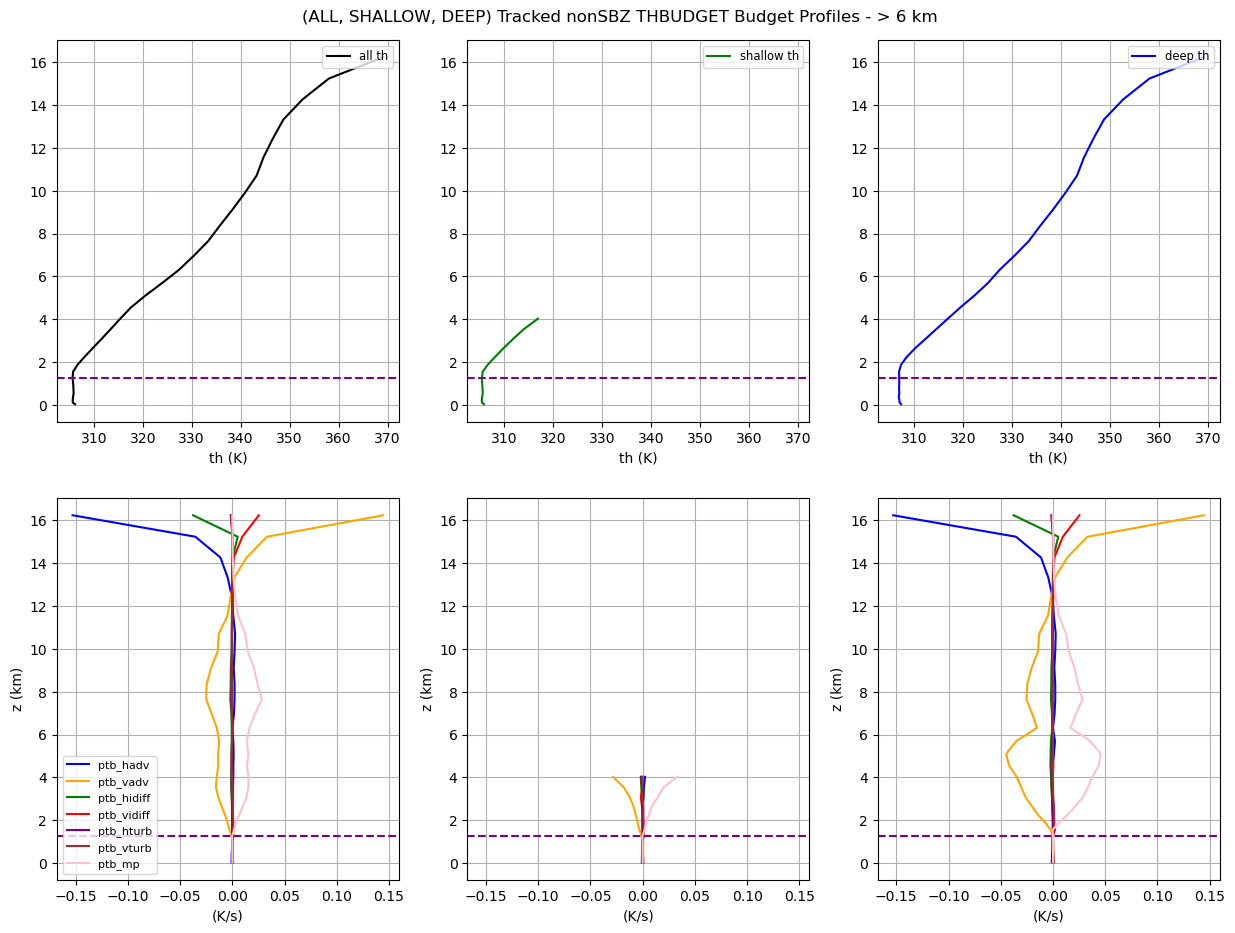

In [101]:
#TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked nonSBZ THBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_THBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_THBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_THBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower left', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(mean_LFC(ALL_nonSBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(mean_LFC(SHALLOW_nonSBZ_out_arr),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(mean_LFC(DEEP_nonSBZ_out_arr),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonSBZ_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [ ]:
# SBZ minus nonSBZ

currently on type all
currently on type shallow
currently on type deep
(-3.801274961231541, 2.494305715978037)
(-0.6809093949384988, 14.981097323540599)
(-0.07292710892095518, 0.07164420069753401)
(-0.6809093949384988, 14.981097323540599)


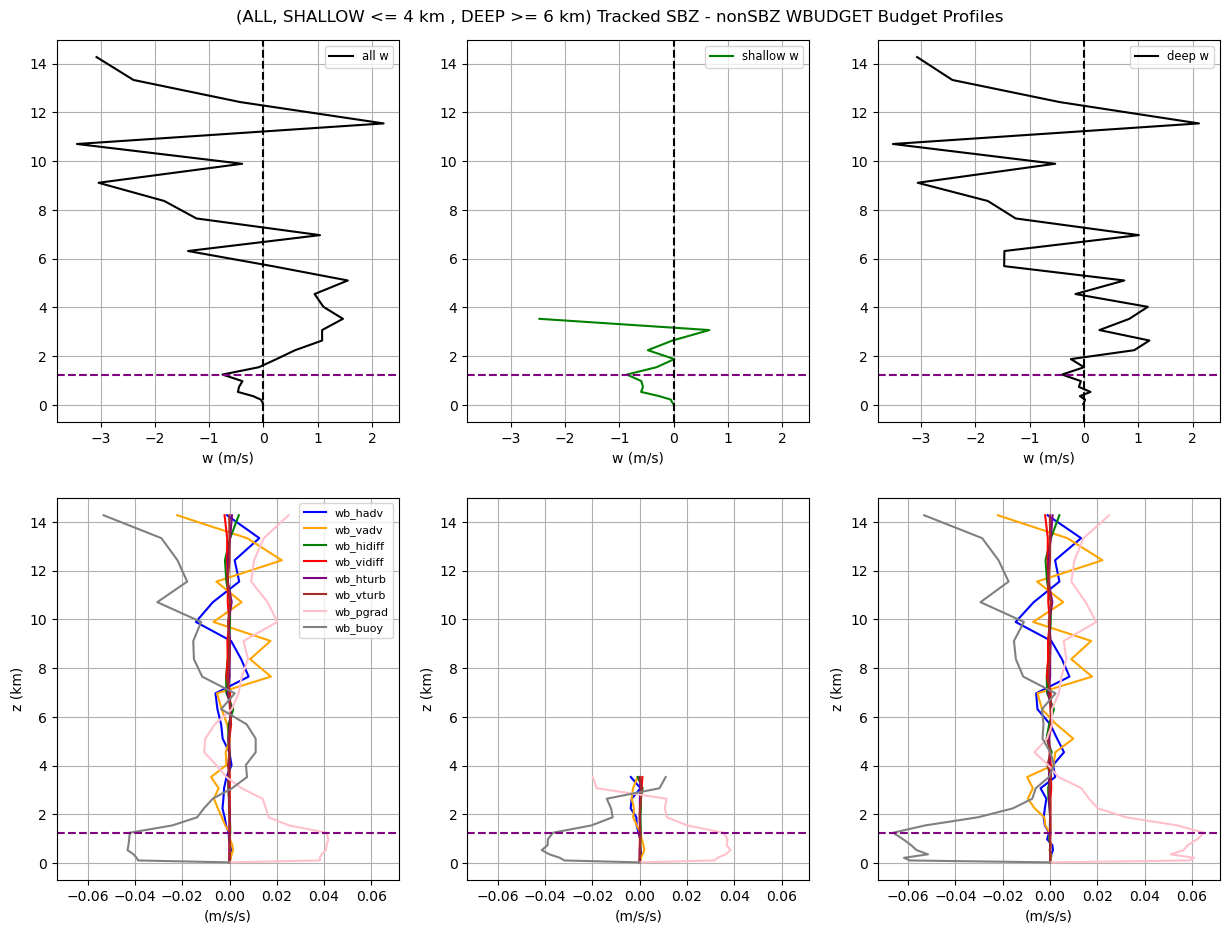

In [103]:

# SBZ minus nonSBZ W BUDGET

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked SBZ - nonSBZ WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

    if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_WBUDGET_profile_all.h5'
    elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w1 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv1 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv1 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff1 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff1 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb1 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb1 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad1 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy1 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy
    
    if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_WBUDGET_profile_all.h5'
    elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w2 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv2 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv2 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff2 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff2 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb2 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb2 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad2 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_buoy2 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_arr), mean_LFC(ALL_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_SBZ_out_arr), mean_LFC(SHALLOW_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_SBZ_out_arr), mean_LFC(DEEP_nonSBZ_out_arr))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusnonSBZ_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.3021548848957221, 1.6316395504208454)
(-0.6809093949384988, 14.981097323540599)
(-0.006789896459697345, 0.0050441266714182234)
(-0.6809093949384988, 14.981097323540599)


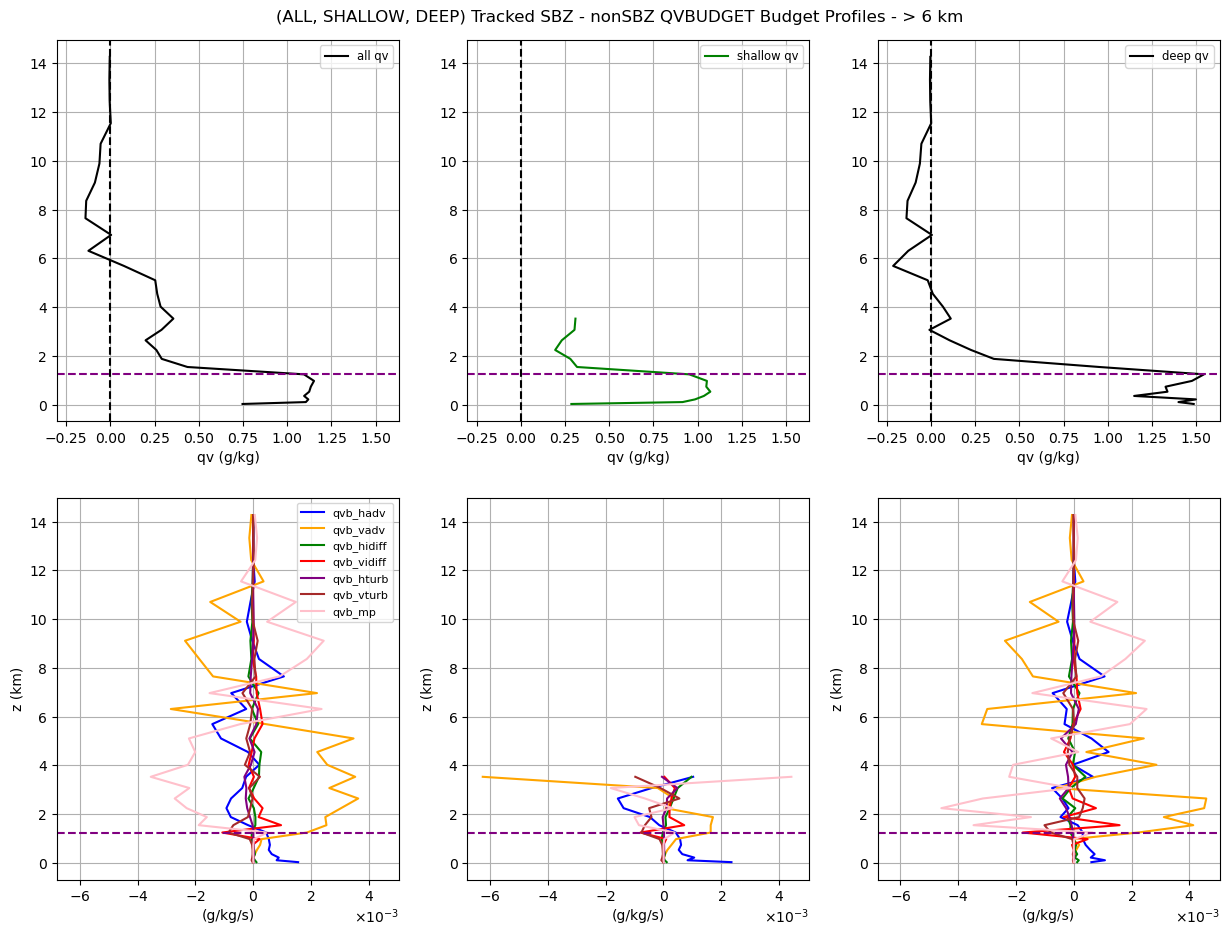

In [104]:
# SBZ minus nonSBZ QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ - nonSBZ QVBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

     
    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_QVBUDGET_profile_all.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_QVBUDGET_profile_shallow.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv1 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv1 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv1 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff1 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff1 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb1 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb1 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp1 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_QVBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_QVBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv2 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv2 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv2 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff2 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff2 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb2 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb2 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp2 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        globals()[f"out_{var}"][:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_arr), mean_LFC(ALL_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_SBZ_out_arr), mean_LFC(SHALLOW_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_SBZ_out_arr), mean_LFC(DEEP_nonSBZ_out_arr))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusnonSBZ_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(-2.4247312531743264, 0.7642131533516789)
(-0.6809093949384988, 14.981097323540599)
(-0.01287967373745566, 0.014828723709407582)
(-0.6809093949384988, 14.981097323540599)


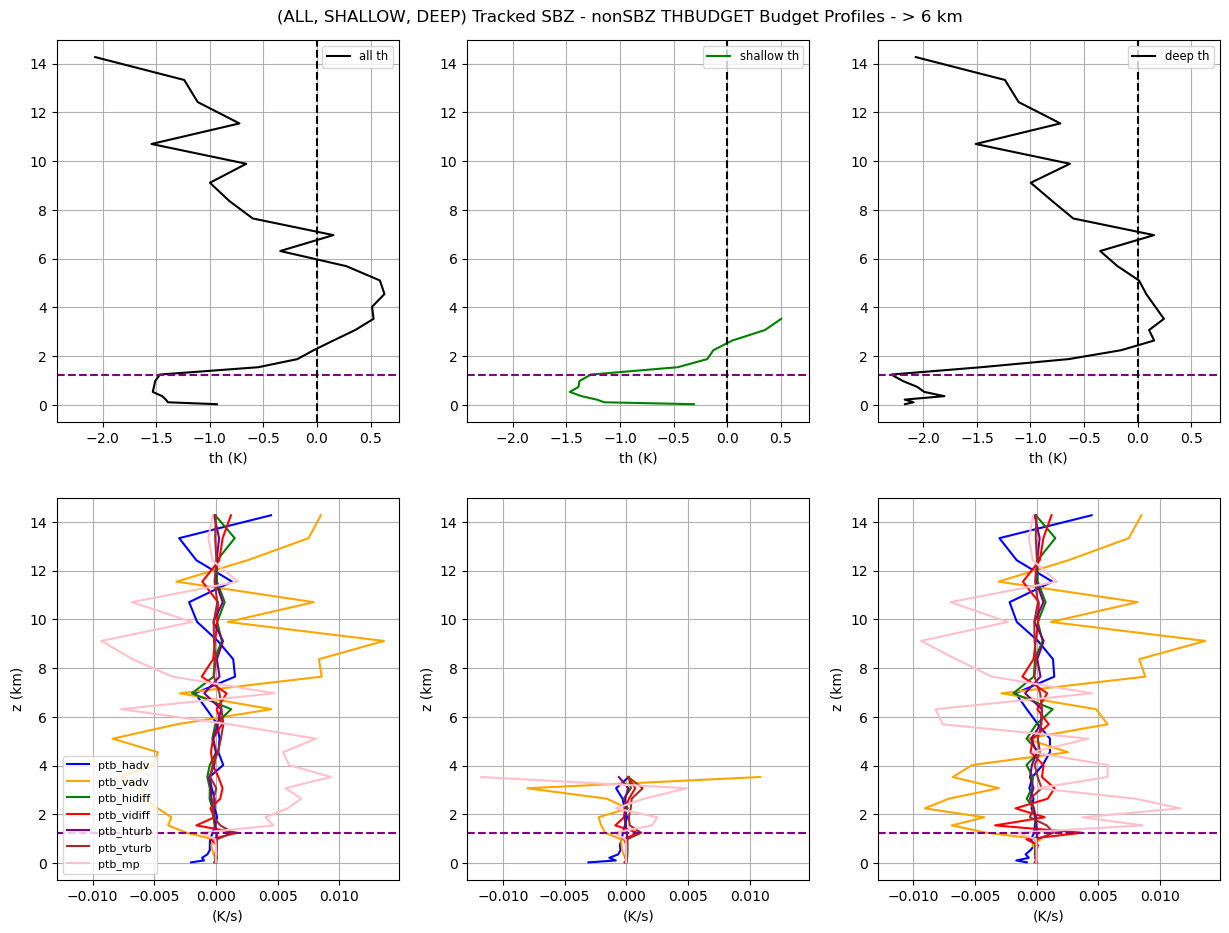

In [105]:
# SBZ minus nonSBZ TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ - nonSBZ THBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')


    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_THBUDGET_profile_all.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_THBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th1 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv1 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv1 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff1 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff1 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb1 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb1 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp1 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient

    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_THBUDGET_profile_all.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_THBUDGET_profile_deep.h5'

    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th2 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv2 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv2 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff2 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff2 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb2 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb2 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp2 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[3])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower left', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3]);fix_y_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6]);fix_y_limits([ax4, ax5, ax6])

# #MEAN LFC 
# for axis in [ax1,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_SBZ_out_arr), mean_LFC(ALL_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax2,ax5]:
#     axis.axhline(np.mean((mean_LFC(SHALLOW_SBZ_out_arr), mean_LFC(SHALLOW_nonSBZ_out_arr))),color='blue',linestyle='dashed')
# for axis in [ax3,ax6]:
#     axis.axhline(np.mean((mean_LFC(DEEP_SBZ_out_arr), mean_LFC(DEEP_nonSBZ_out_arr))),color='blue',linestyle='dashed')

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')


#SCIENTIFIC NOTATION
apply_scientific_notation([ax1, ax2, ax3])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusnonSBZ_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited